In [1]:
"""
L2 minimization problem [-1,1]^d 
The following three tasks are carried out. 
1. u(x) = \Pi_{i=1}^d \sin(\frac{\pi}{2} x_i), (\omega,b) \sim S^d
2. u(x) = \sin(\1/d \sum_{i=1}^d x_i), (\omega,b) \sim S^d
3. u(x) = \sin(\1/d \sum_{i=1}^d x_i), fix \omage = 1, b \sim [-2d^0.5,2d^0.5]
"""
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import sys
import scipy 
from scipy.sparse import linalg
from pathlib import Path
import itertools
import sympy as sp
import math  
if torch.cuda.is_available():  
    device = "cuda" 
else:  
    device = "cpu" 

torch.set_default_dtype(torch.float64)
pi = torch.tensor(np.pi,dtype=torch.float64)
ZERO = torch.tensor([0.]).to(device)

class model(nn.Module):
    """ ReLU k shallow neural network
    Parameters: 
    input size: input dimension
    hidden_size1 : number of hidden layers 
    num_classes: output classes 
    k: degree of relu functions
    """
    def __init__(self, input_size, hidden_size1, num_classes,k = 1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, num_classes,bias = False)
        self.k = k 
    def forward(self, x):
        u1 = self.fc2(F.relu(self.fc1(x))**self.k)
        return u1
    def evaluate_derivative(self, x, i):
        if self.k == 1:
            u1 = self.fc2(torch.heaviside(self.fc1(x),ZERO) * self.fc1.weight.t()[i-1:i,:] )
        else:
            u1 = self.fc2(self.k*F.relu(self.fc1(x))**(self.k-1) *self.fc1.weight.t()[i-1:i,:] )  
        return u1


def PiecewiseGQ1D_weights_points(x_l,x_r,Nx, order):
    """ Output the coeffients and weights for piecewise Gauss Quadrature 
    Parameters
    ----------
    x_l : float 
    left endpoint of an interval 
    
    x_r: float
    right endpoint of an interval 
    
    integration_intervals: int
    number of subintervals for integration
    
    Returns
    -------
    coef1_expand
    
    gw_expand
    
    integration_points
    """
    x,w = np.polynomial.legendre.leggauss(order)
    gx = torch.tensor(x).to(device)
    gx = gx.view(1,-1) # row vector 
    gw = torch.tensor(w).to(device)    
    gw = gw.view(-1,1) # Column vector 
    nodes = torch.linspace(x_l,x_r,Nx+1).view(-1,1).to(device) 
    coef1 = ((nodes[1:,:] - nodes[:-1,:])/2) # n by 1  
    coef2 = ((nodes[1:,:] + nodes[:-1,:])/2) # n by 1  
    coef2_expand = coef2.expand(-1,gx.size(1)) # Expand to n by p shape, -1: keep the first dimension n , expand the 2nd dim (columns)
    integration_points = coef1@gx + coef2_expand
    integration_points = integration_points.flatten().view(-1,1) # Make it a column vector
    gw_expand = torch.tile(gw,(Nx,1)) # rows: n copies of current tensor, columns: 1 copy, no change
    # Modify coef1 to be compatible with func_values
    coef1_expand = coef1.expand(coef1.size(0),gx.size(1))    
    coef1_expand = coef1_expand.flatten().view(-1,1)

    return coef1_expand.to(device)*gw_expand.to(device), integration_points.to(device)


def PiecewiseGQ2D_weights_points(Nx, order,bl = [-1,-1],ur = [1,1]): 
    """ A slight modification of PiecewiseGQ2D function that only needs the weights and integration points.
    Parameters
    Allows a symmetric square domain (around 0) with lower left corner at bl and upper right corner at ur 
    ----------
    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature
    Returns
    -------
    long_weights: torch.tensor
    integration_points: torch.tensor
    """
#     print("order: ",order )
    x, w = np.polynomial.legendre.leggauss(order)
    gauss_pts = np.array(np.meshgrid(x,x,indexing='ij')).reshape(2,-1).T
    weights =  (w*w[:,None]).ravel()

    gauss_pts =torch.tensor(gauss_pts)
    weights = torch.tensor(weights)

    h = (ur[0]- bl[0])/Nx # 100 intervals 
    long_weights =  torch.tile(weights,(Nx**2,1))
    long_weights = long_weights.reshape(-1,1)
    long_weights = long_weights * h**2 /4 

    integration_points = torch.tile(gauss_pts,(Nx**2,1))
    scale_factor = h/2 
    integration_points = scale_factor * integration_points

    index = np.arange(0,Nx)  
    ordered_pairs = np.array(np.meshgrid(index,index,indexing='ij'))
    ordered_pairs = ordered_pairs.reshape(2,-1).T

    # print(ordered_pairs)
    # print()
    ordered_pairs = torch.tensor(ordered_pairs)
    # print(ordered_pairs.size())
    ordered_pairs = torch.tile(ordered_pairs, (1,order**2)) # number of GQ points
    # print(ordered_pairs)

    ordered_pairs =  ordered_pairs.reshape(-1,2)
    # print(ordered_pairs)
    translation = ordered_pairs*h + (torch.tensor(bl) + h/2) 
    # print(translation)

    integration_points = integration_points + translation 
#     print(integration_points.size())
    # func_values = integrand2_torch(integration_points)
    return long_weights.to(device), integration_points.to(device)


def PiecewiseGQ3D_weights_points(Nx, order,bl = [-1,-1,-1],ur = [1,1,1]): 
    """ A slight modification of PiecewiseGQ2D function that only needs the weights and integration points.
    Parameters
    ----------

    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature

    Returns
    -------
    long_weights: torch.tensor
    integration_points: torch.tensor
    """

    """
    Parameters
    ----------
    target : 
        Target function 
    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature
    """

    # print("order: ",order )
    x, w = np.polynomial.legendre.leggauss(order)
    gauss_pts = np.array(np.meshgrid(x,x,x,indexing='ij')).reshape(3,-1).T
    weight_list = np.array(np.meshgrid(w,w,w,indexing='ij'))
    weights =   (weight_list[0]*weight_list[1]*weight_list[2]).ravel() 

    gauss_pts =torch.tensor(gauss_pts)
    weights = torch.tensor(weights)

    # h = 1/Nx # 100 intervals 
    h = (ur[0]- bl[0])/Nx # 100 intervals 
    long_weights =  torch.tile(weights,(Nx**3,1))
    long_weights = long_weights.reshape(-1,1)
    long_weights = long_weights * h**3 /8 

    integration_points = torch.tile(gauss_pts,(Nx**3,1))
    # print("shape of integration_points", integration_points.size())
    scale_factor = h/2 
    integration_points = scale_factor * integration_points

    # index = np.arange(1,Nx+1)-0.5
    index = np.arange(0,Nx)  
    ordered_pairs = np.array(np.meshgrid(index,index,index,indexing='ij'))
    ordered_pairs = ordered_pairs.reshape(3,-1).T

    # print(ordered_pairs)
    # print()
    ordered_pairs = torch.tensor(ordered_pairs)
    # print(ordered_pairs.size())
    ordered_pairs = torch.tile(ordered_pairs, (1,order**3)) # number of GQ points
    # print(ordered_pairs)

    ordered_pairs =  ordered_pairs.reshape(-1,3)
    # print(ordered_pairs)
    # translation = ordered_pairs*h 
    translation = ordered_pairs*h + (torch.tensor(bl) + h/2) 
    # print(translation)

    integration_points = integration_points + translation 

    return long_weights.to(device), integration_points.to(device)

def MonteCarlo_Sobol_dDim_weights_points(M ,d = 4,bl = -1,ur = 1):
    
    length = ur - bl
    vol = length ** d 
    Sob_integral = torch.quasirandom.SobolEngine(dimension =d, scramble= False, seed=None) 
    integration_points = Sob_integral.draw(M).double() 
    integration_points = integration_points.to(device) * length - length/2 
    weights = torch.ones(M,1).to(device)/M * vol 
    return weights.to(device), integration_points.to(device) 



In [2]:
def initialize_model_1d(my_model):
    neuron_nums = my_model.fc1.bias.size(0)
    theta = torch.linspace(0,pi,neuron_nums+1)[:-1]
    W = torch.cos(theta).view(-1,1)
    b = torch.sin(theta)
    my_model.fc1.weight.data[:,:] = W[:,:]
    my_model.fc1.bias.data[:] = b[:] 
    return my_model 
def initialize_model_1(my_model):
    # w ~ U(S^1), b ~ U(-1.42,1.42) 
    neuron_nums = my_model.fc1.bias.size(0)
    samples = torch.rand(neuron_nums,2) 
    T =torch.tensor([[2*pi,0],[0,2.84]])
    shift = torch.tensor([0,-1.42]) 
    samples = samples@T + shift 
    theta = samples[:,0].reshape(neuron_nums,1)
    W1 = torch.cos(theta)
    W2 = torch.sin(theta)
    W = torch.cat((W1,W2),1) # N1 x 2
    b = samples[:,1].reshape(neuron_nums,1)
    my_model.fc1.weight.data[:,:] = W[:,:]
    my_model.fc1.bias.data[:] = b[:,0] 
    
    return my_model 

def initialize_model_2(my_model,dim = 2):
    # (w,b) ~ U(S^2)
    neuron_nums = my_model.fc1.bias.size(0)
    points = torch.randn(neuron_nums,dim + 1)
    points = points/torch.norm(points, dim=1, keepdim=True)
    my_model.fc1.weight.data[:,:] = points[:,0:dim]
    my_model.fc1.bias.data[:] = points[:,dim]  
    return my_model 

def initialize_model_3(my_model):
    # generate a uniform grid on S^2 
    neuron_nums = my_model.fc1.bias.size(0) 

    indices = torch.arange(0, neuron_nums, dtype=torch.float) + 0.5
    phi = torch.acos(1 - 2*indices/neuron_nums)
    theta = pi * (1 + 5**0.5) * indices
    x = torch.sin(phi) * torch.cos(theta)
    y = torch.sin(phi) * torch.sin(theta)
    z = torch.cos(phi)

    points = torch.stack((x, y, z), dim=1)
    my_model.fc1.weight.data[:,:] = points[:,0:2]
    my_model.fc1.bias.data[:] = points[:,2]
    return my_model 

def initialize_model_4(my_model,dim = 2):
    # (w,b) ~ U(S^2)
    neuron_nums = my_model.fc1.bias.size(0)
#     points = torch.randn(neuron_nums,dim + 1)
#     points = points/torch.norm(points, dim=1, keepdim=True)
    my_model.fc1.weight.data[:,:] = torch.ones(neuron_nums,dim)/(dim)  # points[:,0:dim]
    
#     biases = torch.linspace(0,1,neuron_nums)* 4 * dim **0.5 -  2  * dim **0.5
    biases = torch.linspace(0,1,neuron_nums)* 4 -  2 
    my_model.fc1.bias.data[:] = biases[:]  
    return my_model 

def remove_redundant_neuron(my_model, dims = 3, choice = 2): 
    ##  choice 1:  [0,1]^d, choice 2: [-1,1]^d
    def create_mesh_grid(dims, pts):
        mesh = torch.tensor(list(itertools.product(pts,repeat=dims)))
        vertices = mesh.reshape(len(pts) ** dims, -1) 
        return vertices
    counter = 0 
    # positions = torch.tensor([[0.,0.],[0.,1.],[1.,1.],[1.,0.]])
    # pts = torch.tensor([0.,1.]) # for domain [0,1]^d 
    if choice == 1: 
        pts = torch.tensor([0.,1.])
    elif choice == 2:
        pts = torch.tensor([-1.,1.])# for domain [-1,1]^d 
    elif choice == 3:
        pts = torch.tensor([-1./2,1./2])# for domain [-1,1]^d 
    positions = create_mesh_grid(dims,pts) 
    neuron_num = my_model.fc1.bias.size(0)
    relu_k = my_model.k 
    recorded_neurons = []
    poly_dofs = math.comb(relu_k + dims, dims)
    for i in range(neuron_num): 
        w = my_model.fc1.weight.data[i:i+1,:]
        b = my_model.fc1.bias.data[i]
        values = torch.matmul(positions,w.T)
        left_end = - torch.max(values)
        right_end = - torch.min(values)
        offset = (right_end - left_end)/50
        if b > left_end + offset/2 and b < right_end - offset/2: 
            recorded_neurons.append((w, b))
        elif b >= right_end - offset/2 and counter < poly_dofs:
            recorded_neurons.append((w, b))
            counter += 1

    new_neuron_num = len(recorded_neurons)
    new_model = model(dims, new_neuron_num, 1, k=relu_k).to(device)
    for i, (w, b) in enumerate(recorded_neurons):
        new_model.fc1.weight.data[i:i+1,:] = w
        new_model.fc1.bias.data[i] = b
    print("Number of neurons removed: ", neuron_num - new_neuron_num)
    print("Number of neurons left: ", new_neuron_num)  
    return new_model


In [3]:
def plot_2D(f): 
    
    Nx = 200
    Ny = 200 
    xs = np.linspace(-1, 1, Nx)
    ys = np.linspace(-1, 1, Ny)
    x, y = np.meshgrid(xs, ys, indexing='xy')
    xy_comb = np.stack((x.flatten(),y.flatten())).T
    xy_comb = torch.tensor(xy_comb)
    z = f(xy_comb).reshape(Nx,Ny)
    z = z.detach().numpy()
    plt.figure(dpi=200)
    ax = plt.axes(projection='3d')
    ax.plot_surface(x , y , z )

    plt.show()

In [4]:
def assemble_least_square_linear_system_quadrature(model,rhs, integration_weights,integration_points): 
    """ Assemble the least square linear system, D: design matrix, b right hand side """
    in_feat, out_feat = model.fc1.weight.shape 
    relu_k = model.k 
    W = model.fc1.weight.data  # shape: (M, d+1)
    b = model.fc1.bias.data  # shape: (M,)
    Z = integration_points@ W.t() + b  
    D = (F.relu(Z)**relu_k)  * integration_weights  
    b_rhs = rhs(integration_points) * integration_weights 
    return D,b_rhs

def rescale_mat_rhs(A,f):
    c = 100.0
    for i in range(len(A)):
        max_a = abs(A[i,:]).max()
        max_b = A[i,:].max()
        if max_a != max_b: 
            ratio = -c/max_a
            A[i,:] = A[i,:]*ratio
            f[i] = f[i]*ratio
        else: 
            ratio = c/max_a
            A[i,:] = A[i,:]*ratio
            f[i] = f[i]*ratio
    return A,f 



In [10]:
# show convergence order 
def output_convergence_order_l2(neuron_nums,err_list_l2): 
    print("$n$ & \t $\|u-u_n \|_{L^2}$ & \t order  \\\ \hline \hline ")
    for i, item in enumerate(err_list_l2):
        if i == 0: 
            print("{} \t\t & {:.3e} &\t\t *  \\\ \hline  \n".format(neuron_nums[i],item))    
        else: 
            print("{} \t\t &  {:.3e} &  \t\t {:.2f}  \\\ \hline  \n".format(neuron_nums[i],item, np.log(err_list_l2[i-1]/err_list_l2[i])/np.log(neuron_nums[i]/neuron_nums[i-1]) ) )

def plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title): 
    optimal_rate = 1/2 + (2 * relu_k +1)/(2*d)
    ref = mean_err_l2_arr[0] *actual_neuron_arr[0]**optimal_rate * (actual_neuron_arr)**(-optimal_rate)
    plt.figure(dpi=400)
    plt.plot(actual_neuron_arr,ref,'-.',label = 'optimal slope: -{:.2f}'.format(optimal_rate))
    plt.plot(actual_neuron_arr, mean_err_l2_arr, '.-', label = 'ReLU$^{}$'.format(relu_k), linewidth = 2)
    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.ylabel("$L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show() 

Number of neurons removed:  2
Number of neurons left:  6
Number of neurons removed:  6
Number of neurons left:  10
Number of neurons removed:  14
Number of neurons left:  18
Number of neurons removed:  30
Number of neurons left:  34


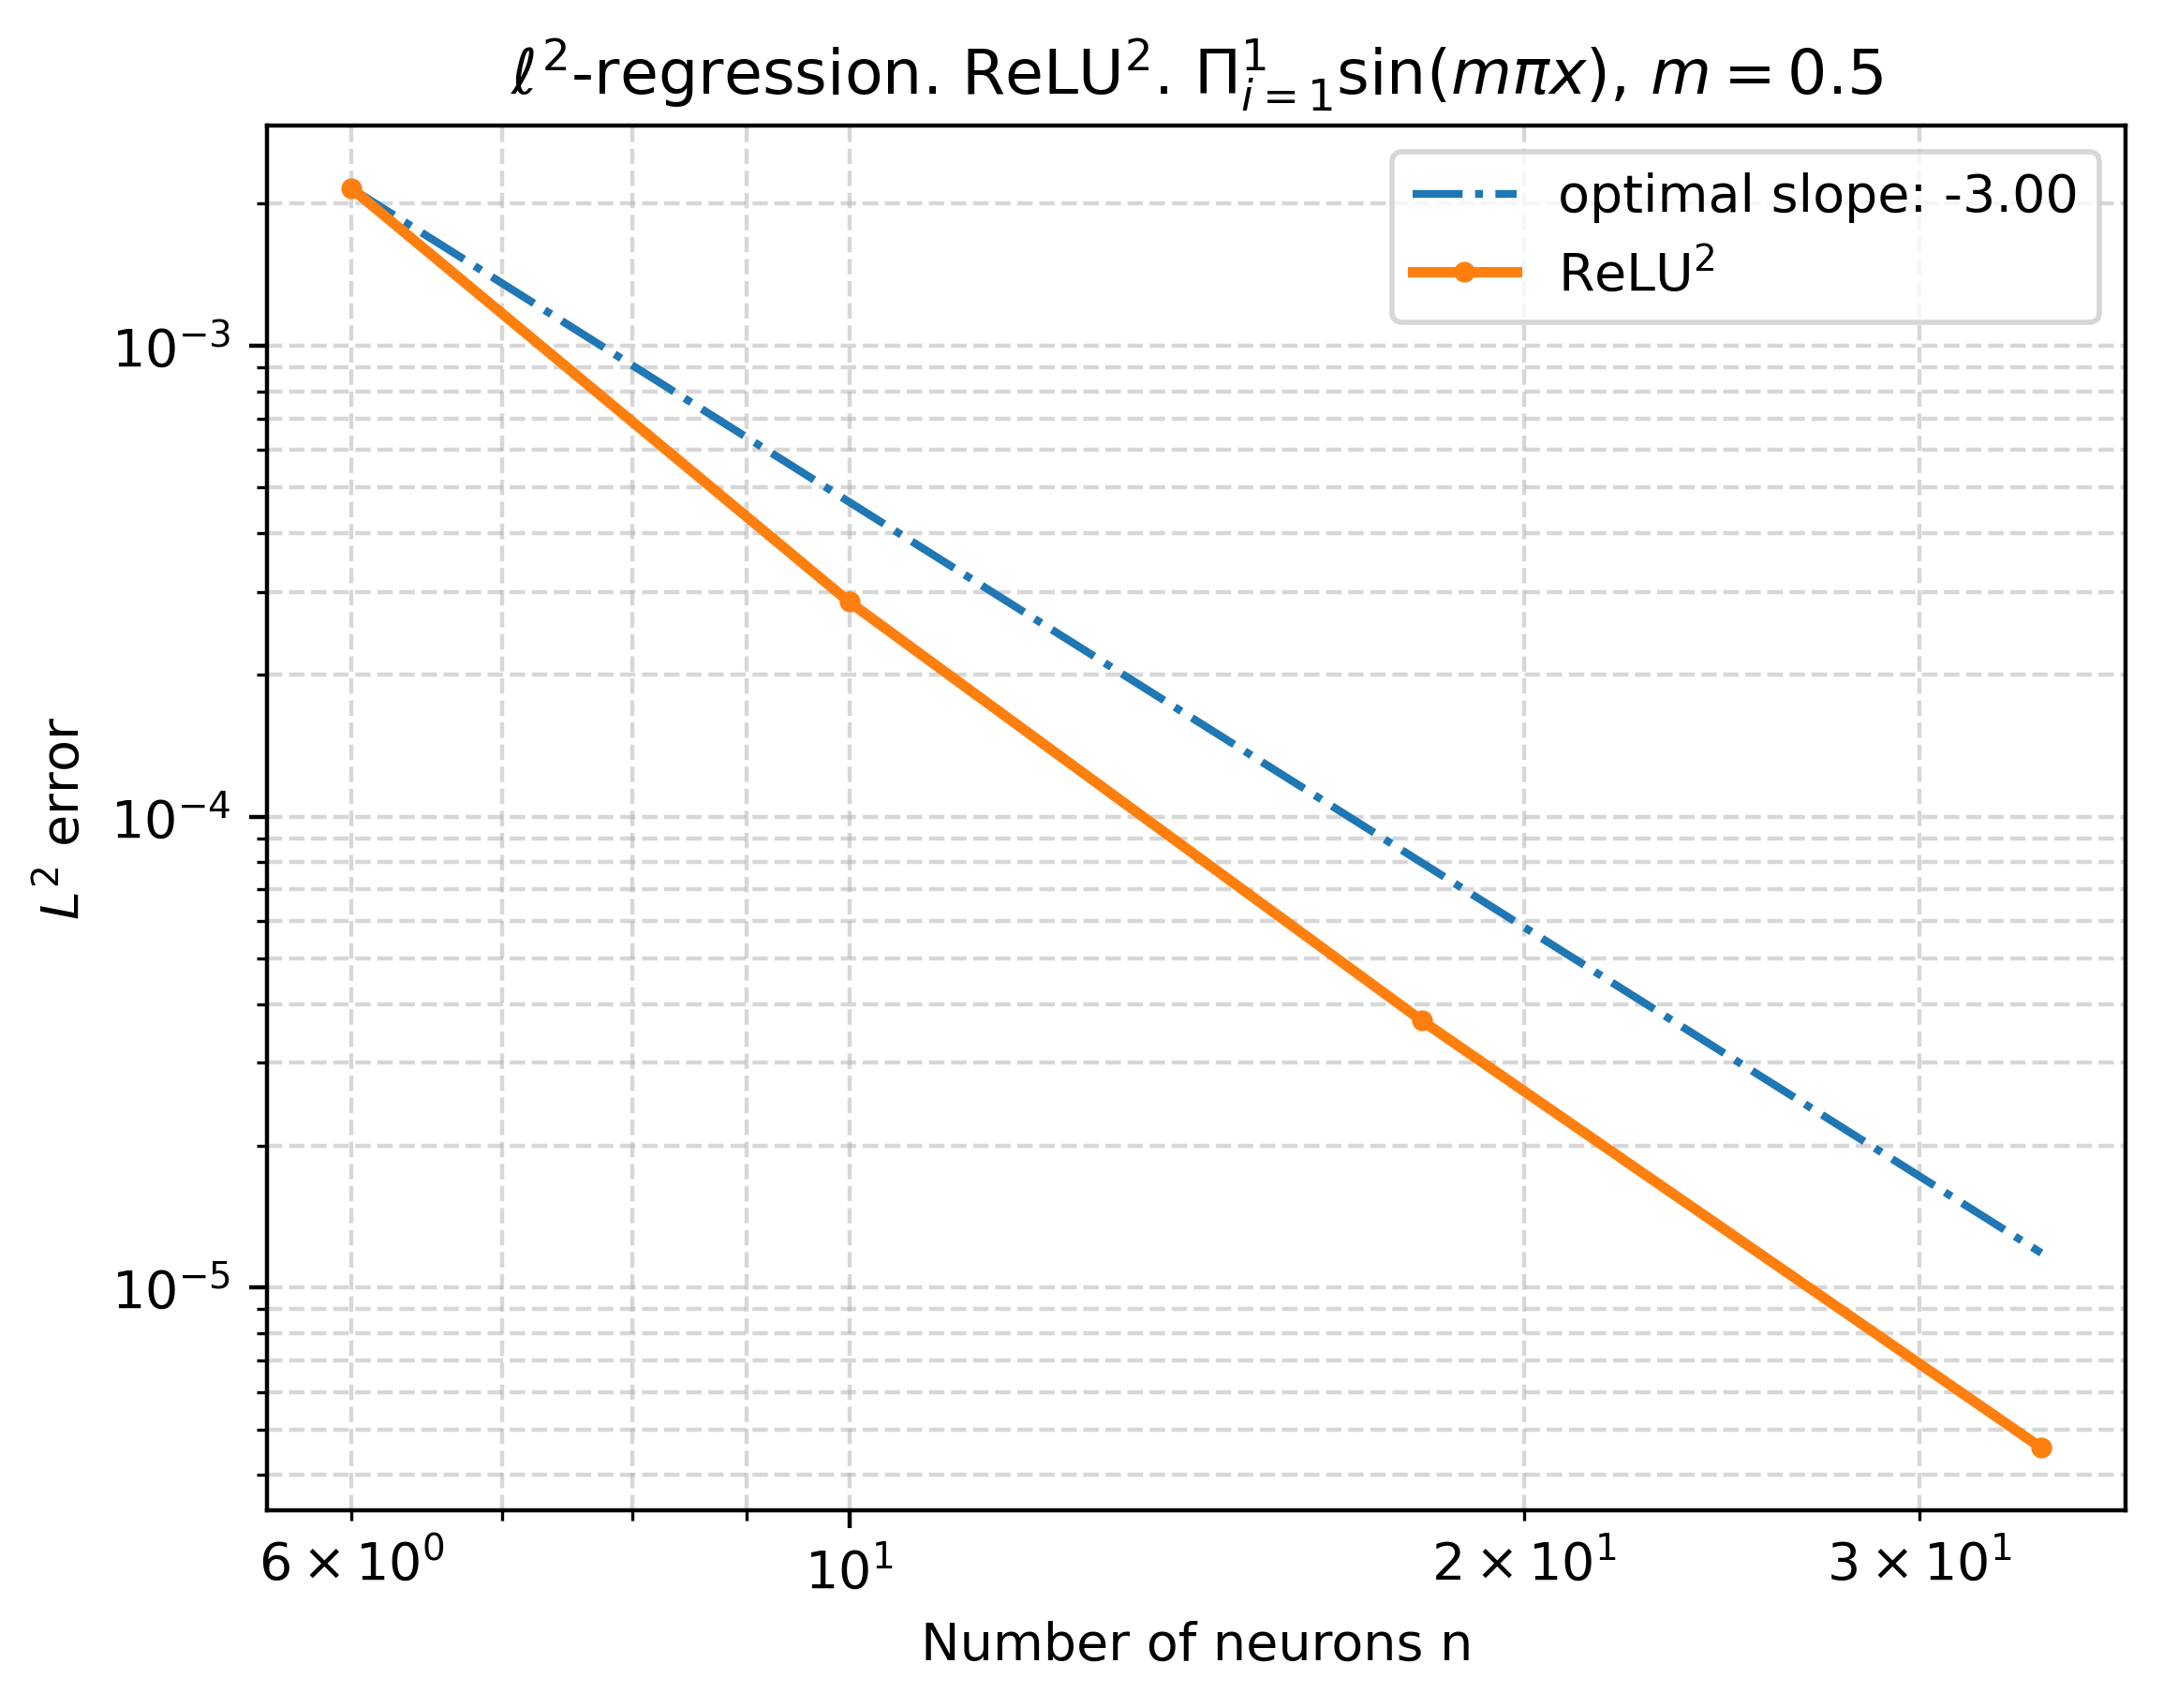

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
6.0 		 & 2.154e-03 &		 *  \\ \hline  

10.0 		 &  2.855e-04 &  		 3.96  \\ \hline  

18.0 		 &  3.687e-05 &  		 3.48  \\ \hline  

34.0 		 &  4.568e-06 &  		 3.28  \\ \hline  



In [14]:
## 1D 
m = 1/2 

def target(x): 
    z = torch.sin(m * pi*x[:,0:1]) 
    return z 
relu_k = 2
d = 1  
# collocation points and weights 

x_train = torch.linspace(-1,1,2048).view(-1,1).to(device)
integration_weights = (1/x_train.size(0))
integration_points = x_train.to(device)

integration_weights_test, integration_points_test = PiecewiseGQ1D_weights_points(x_l = -1,x_r = 1,Nx = 1024, order = 3)

mean_err_l2_list = [] # mean squared error 
mean_err_l2_list_2 = [] #exact L^2 error 
neuron_num_arr= np.array([2**i for i in range(3,7)]) 
actual_neuron_arr = np.zeros(len(neuron_num_arr)) 
for i,n in enumerate(neuron_num_arr): 
    trial_num = 1
    err_l2_trial = torch.zeros(trial_num) 
    err_l2_trial_2 = torch.zeros(trial_num)
    for trial in range(trial_num):
        #1. initialize model 
        my_model = model(d, n, 1, k=relu_k).to(device) 
        #2. remove redundant neurons
        # my_model = initialize_model_3(my_model.cpu()).to(device) 
        my_model = initialize_model_1d(my_model)
        
        my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
        actual_neuron_arr[i] = my_model.fc1.bias.size(0) 

        D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
        D, b_rhs = rescale_mat_rhs(D,b_rhs)
        sol = scipy.linalg.lstsq(D.cpu().numpy(),b_rhs.cpu().numpy())[0]
        sol =torch.tensor(sol).to(device)
        my_model.fc2.weight.data[0,:] = sol.view(-1) 

        # with torch.no_grad(): 
        #     nn_func_values = my_model(x_test) 
        # target_values = target(x_test) 
        # target_norm = target_values.norm()
        # print(target_norm)
        # rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
        # err_l2_trial[trial] = rel_errl2 

        #evaluate error using exact Gauss quadrature rule
        with torch.no_grad():
            nn_func_values_2 = my_model(integration_points_test)
        target_values_2 = target(integration_points_test)
        # target_norm_2 = target_values_2.norm()
        rel_errl2_2 = integration_weights_test.t() @ (nn_func_values_2 - target_values_2)**2
        err_l2_trial_2[trial] = rel_errl2_2**0.5 

 
    # mean_err_l2_list.append(torch.mean(err_l2_trial)) 

    mean_err_l2_list_2.append(torch.mean(err_l2_trial_2))

mean_err_l2_arr_2 = np.array(mean_err_l2_list_2) 

if relu_k == 1:
    title =f"$\ell^2$-regression. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
else:
    title = f"$\ell^2$-regression. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
# plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title)
# output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr)
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)




In [ ]:
## 2D 

Number of neurons removed:  9
Number of neurons left:  55
Number of neurons removed:  22
Number of neurons left:  106
Number of neurons removed:  51
Number of neurons left:  205
Number of neurons removed:  110
Number of neurons left:  402
Number of neurons removed:  221
Number of neurons left:  803
Number of neurons removed:  453
Number of neurons left:  1595
Number of neurons removed:  907
Number of neurons left:  3189


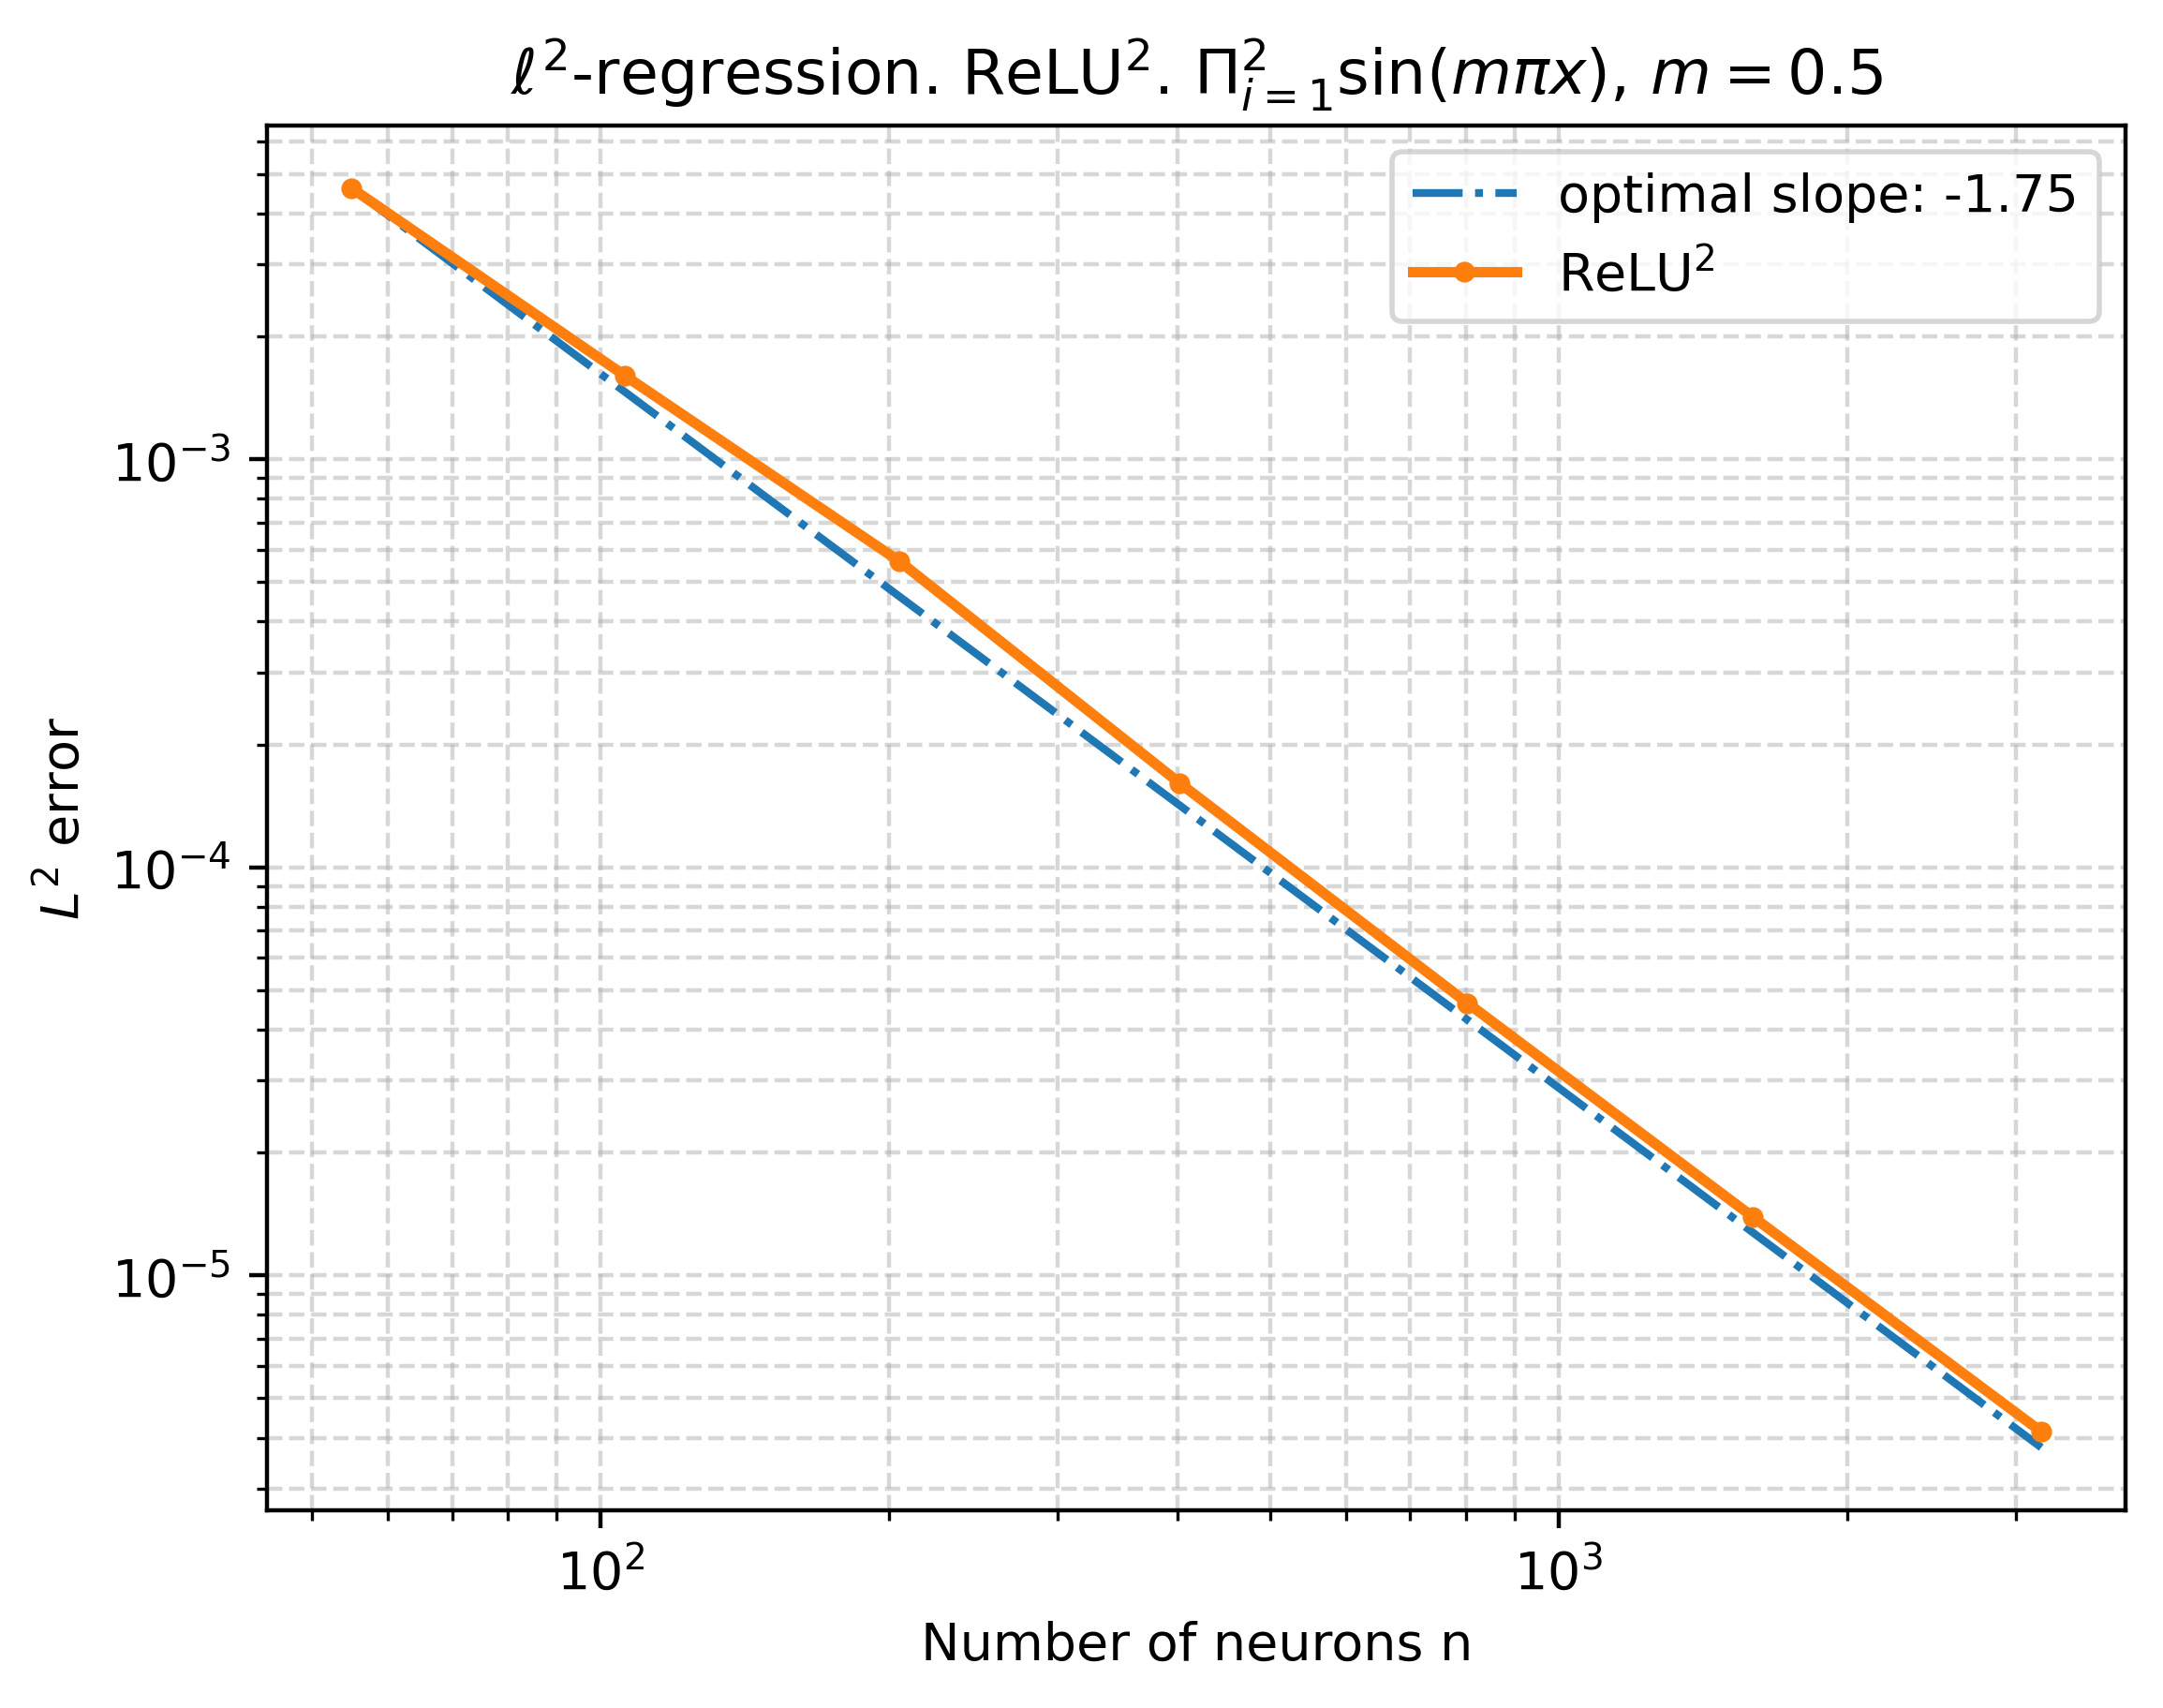

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
55.0 		 & 4.612e-03 &		 *  \\ \hline  

106.0 		 &  1.603e-03 &  		 1.61  \\ \hline  

205.0 		 &  5.626e-04 &  		 1.59  \\ \hline  

402.0 		 &  1.610e-04 &  		 1.86  \\ \hline  

803.0 		 &  4.649e-05 &  		 1.79  \\ \hline  

1595.0 		 &  1.390e-05 &  		 1.76  \\ \hline  

3189.0 		 &  4.139e-06 &  		 1.75  \\ \hline  



In [15]:
m = 1/2 

def target(x): 
    z = torch.sin(m * pi*x[:,0:1])*torch.sin(m * pi*x[:,1:2] ) # * torch.sin(pi/2*x[:,2:3])  
    return z 
relu_k = 2
d = 2 
# collocation points and weights 
x = torch.linspace(-1,1,100)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = (1/x_train.size(0))
integration_points = x_train.to(device)
x = torch.linspace(-1,1,300)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)

integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(200, 3, bl = [-1,-1], ur = [1,1])

mean_err_l2_list = [] # mean squared error 
mean_err_l2_list_2 = [] #exact L^2 error 
neuron_num_arr= np.array([2**i for i in range(6,13)]) 
actual_neuron_arr = np.zeros(len(neuron_num_arr)) 
for i,n in enumerate(neuron_num_arr): 
    trial_num = 1
    err_l2_trial = torch.zeros(trial_num) 
    err_l2_trial_2 = torch.zeros(trial_num)
    for trial in range(trial_num):
        #1. initialize model 
        my_model = model(2, n, 1, k=relu_k).to(device) 
        #2. remove redundant neurons
        my_model = initialize_model_3(my_model.cpu()).to(device) 
        my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
        actual_neuron_arr[i] = my_model.fc1.bias.size(0) 

        D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
        D, b_rhs = rescale_mat_rhs(D,b_rhs)
        sol = scipy.linalg.lstsq(D.cpu().numpy(),b_rhs.cpu().numpy())[0]
        sol =torch.tensor(sol).to(device)
        my_model.fc2.weight.data[0,:] = sol.view(-1) 

        # with torch.no_grad(): 
        #     nn_func_values = my_model(x_test) 
        # target_values = target(x_test) 
        # target_norm = target_values.norm()
        # print(target_norm)
        # rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
        # err_l2_trial[trial] = rel_errl2 

        #evaluate error using exact Gauss quadrature rule
        with torch.no_grad():
            nn_func_values_2 = my_model(integration_points_test)
        target_values_2 = target(integration_points_test)
        # target_norm_2 = target_values_2.norm()
        rel_errl2_2 = integration_weights_test.t() @ (nn_func_values_2 - target_values_2)**2
        err_l2_trial_2[trial] = rel_errl2_2**0.5 

 
    # mean_err_l2_list.append(torch.mean(err_l2_trial)) 

    mean_err_l2_list_2.append(torch.mean(err_l2_trial_2))

# mean_err_l2_arr = np.array(mean_err_l2_list) 
mean_err_l2_arr_2 = np.array(mean_err_l2_list_2) 


if relu_k == 1:
    title =f"$\ell^2$-regression. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
else:
    title = f"$\ell^2$-regression. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
# plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title)
# output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr)
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)




## relu 2


## 3D results 

Number of neurons removed:  2
Number of neurons left:  62
Number of neurons removed:  3
Number of neurons left:  125
Number of neurons removed:  12
Number of neurons left:  244
Number of neurons removed:  46
Number of neurons left:  466
Number of neurons removed:  86
Number of neurons left:  938
Number of neurons removed:  156
Number of neurons left:  1892


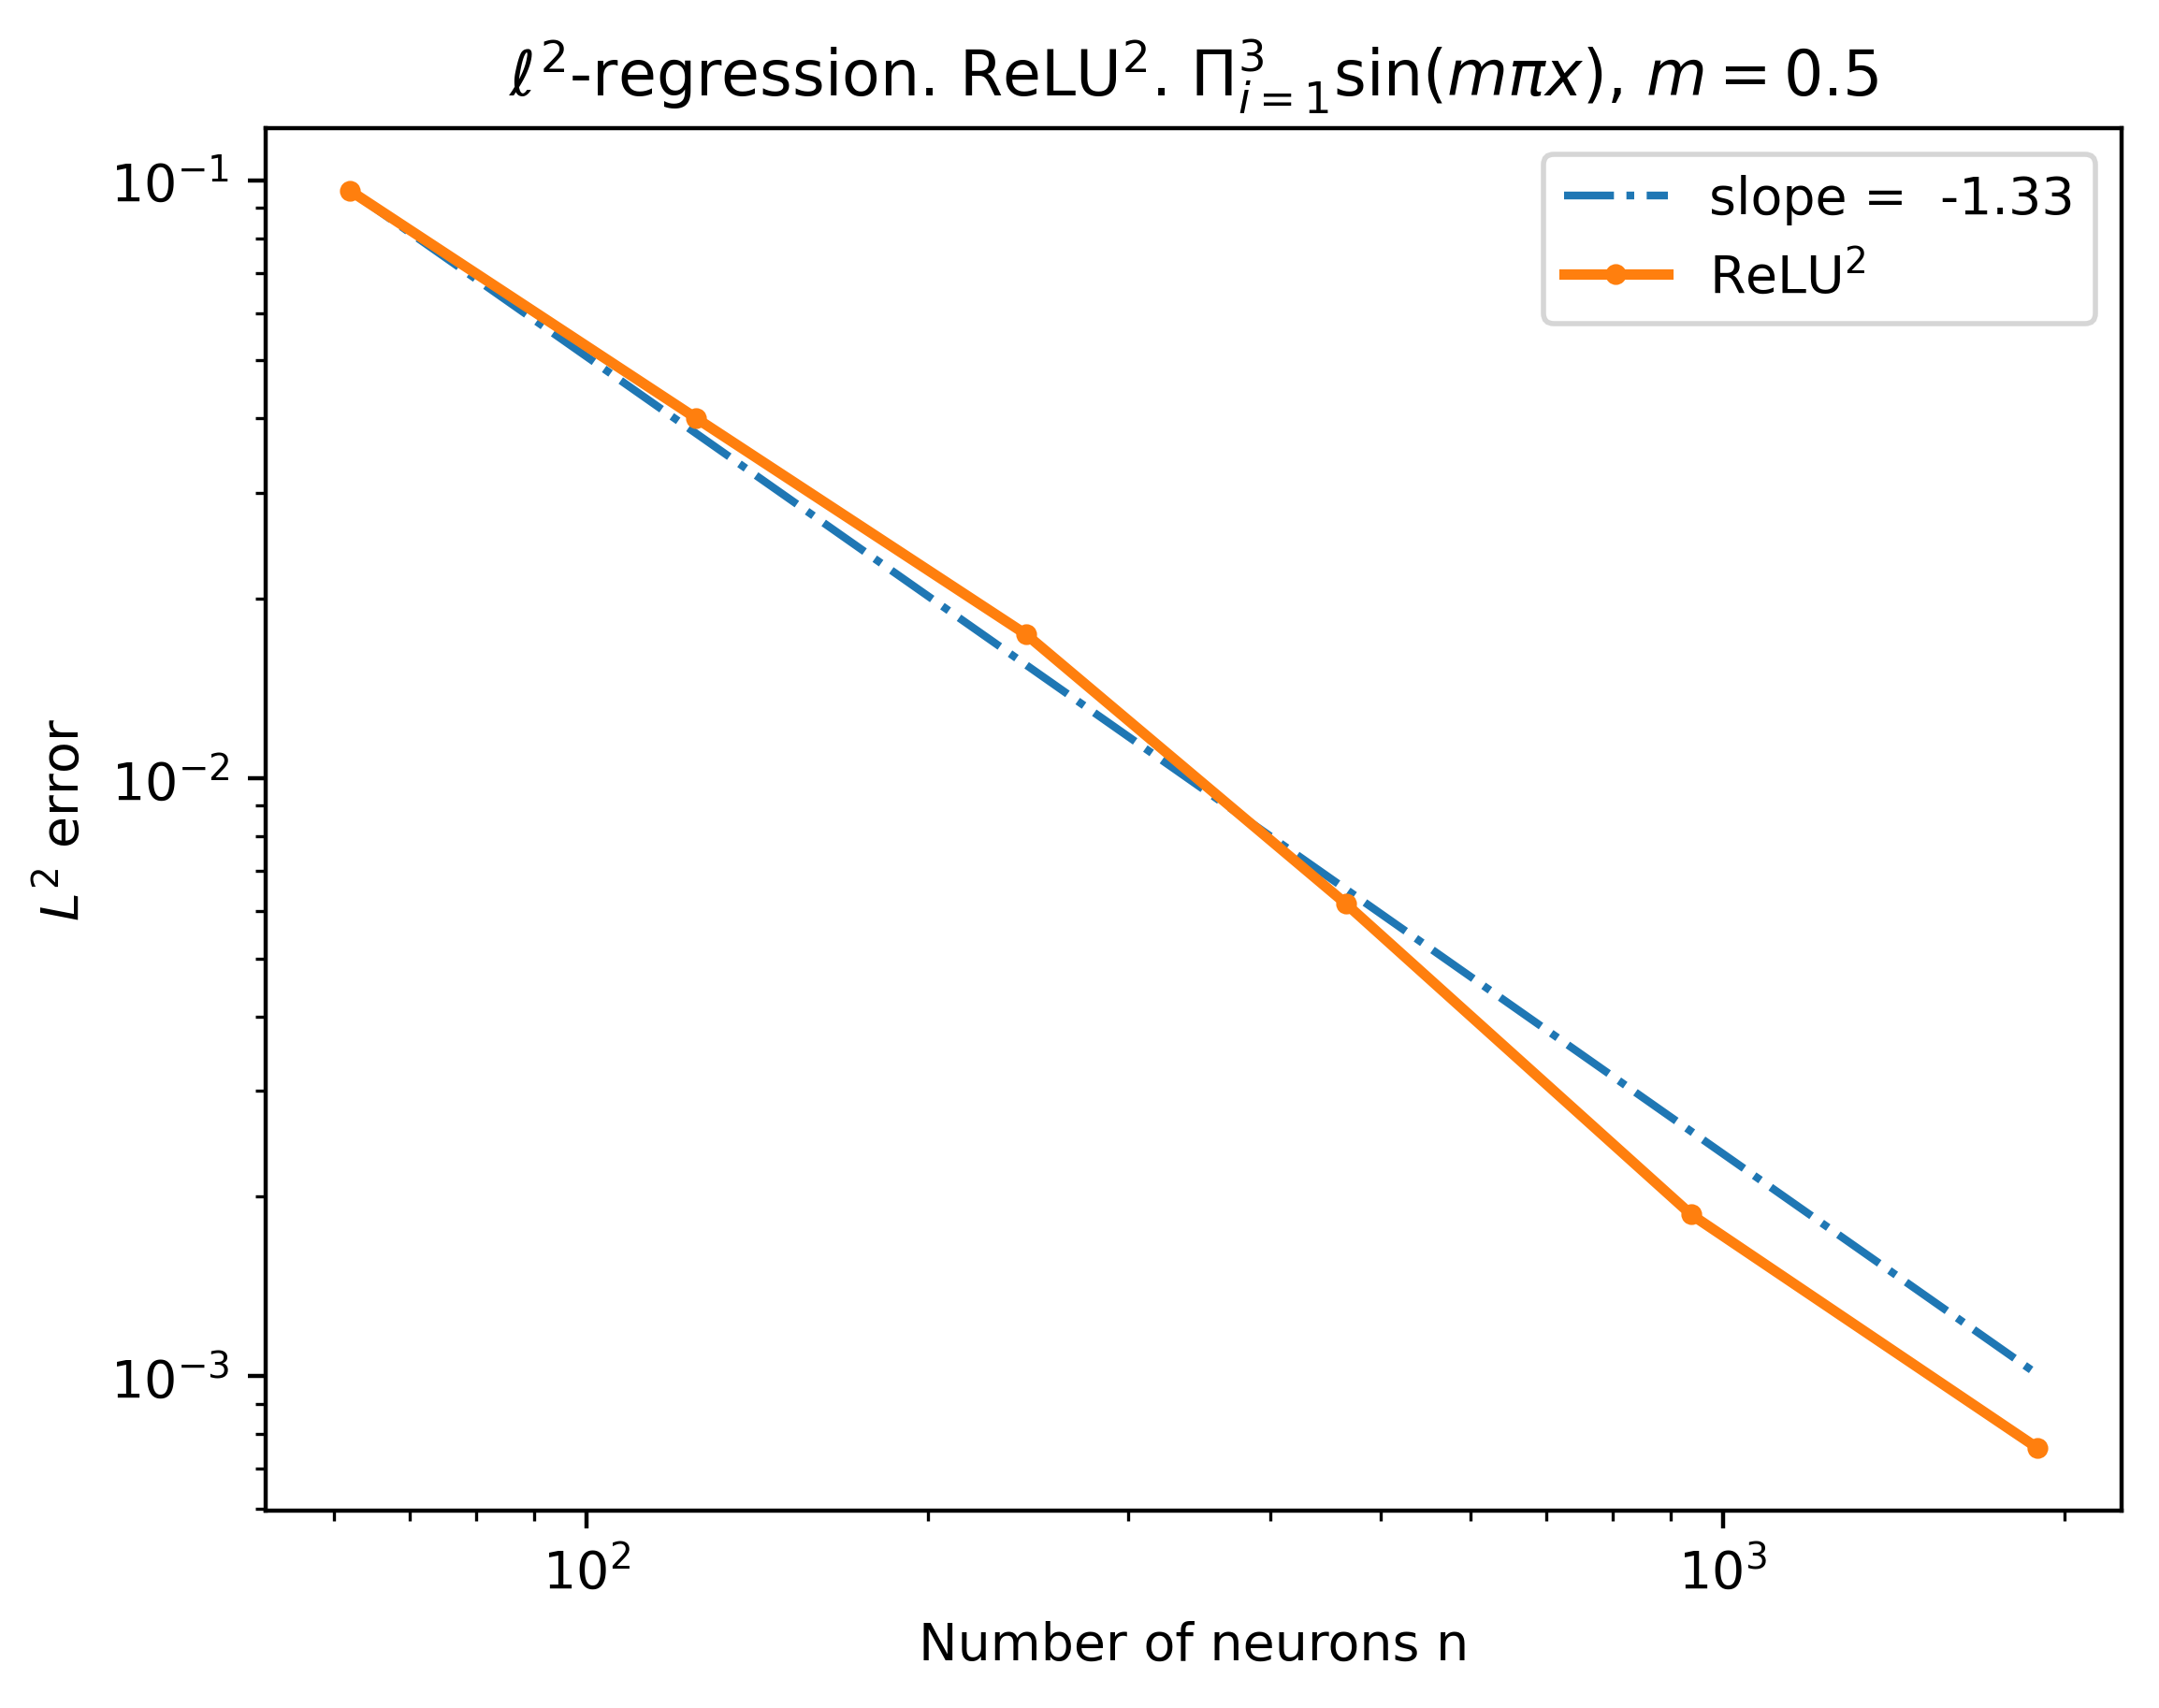

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
62.0 		 & 9.614e-02 &		 *  \\ \hline  

125.0 		 &  4.004e-02 &  		 1.25  \\ \hline  

244.0 		 &  1.740e-02 &  		 1.25  \\ \hline  

466.0 		 &  6.176e-03 &  		 1.60  \\ \hline  

938.0 		 &  1.866e-03 &  		 1.71  \\ \hline  

1892.0 		 &  7.592e-04 &  		 1.28  \\ \hline  



In [42]:
m1 = 1/2 
m2 = 1/2  
m3 = 1/2 

def target(x): 
    z = torch.sin(m1 * pi *x[:,0:1])*torch.sin(m2 * pi *x[:,1:2] ) * torch.sin(m3 * pi *x[:,2:3])  
    return z 
relu_k = 2 
d = 3 
# collocation points and weights 
x = torch.linspace(-1,1,50)
X1, X2, X3 = torch.meshgrid(x,x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1), X3.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train.to(device) 
x = torch.linspace(-1,1,100)
X1, X2, X3 = torch.meshgrid(x,x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1), X3.reshape(-1,1)], dim=1)

integration_weights_test, integration_points_test = PiecewiseGQ3D_weights_points(20, 3, bl = [-1,-1,-1], ur = [1,1,1])

mean_err_l2_list = [] # mean squared error 
mean_err_l2_list_2 = [] #exact L^2 error 
neuron_num_arr= np.array([2**i for i in range(6,12)]) 
actual_neuron_arr = np.zeros(len(neuron_num_arr)) 
for i,n in enumerate(neuron_num_arr): 
    trial_num = 1
    err_l2_trial = torch.zeros(trial_num) 
    err_l2_trial_2 = torch.zeros(trial_num)
    for trial in range(trial_num):
        #1. initialize model 
        my_model = model(d, n, 1, k=relu_k).to(device) 
        #2. remove redundant neurons
        my_model = initialize_model_2(my_model.cpu(), dim = d).to(device) 
        my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device)
        actual_neuron_arr[i] = my_model.fc1.bias.size(0) 
        D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
        D, b_rhs = rescale_mat_rhs(D,b_rhs)
        sol = scipy.linalg.lstsq(D.cpu().numpy(),b_rhs.cpu().numpy())[0]
        sol =torch.tensor(sol)
        my_model.fc2.weight.data[0,:] = sol.view(-1) 

        # with torch.no_grad(): 
        #     nn_func_values = my_model(x_test) 
        # target_values = target(x_test) 
        # target_norm = target_values.norm()
        # print(target_norm)
        # rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
        # err_l2_trial[trial] = rel_errl2 

        #evaluate error using exact Gauss quadrature rule
        with torch.no_grad():
            nn_func_values_2 = my_model(integration_points_test)
        target_values_2 = target(integration_points_test)
        # target_norm_2 = target_values_2.norm()
        rel_errl2_2 = integration_weights_test.t() @ (nn_func_values_2 - target_values_2)**2
        err_l2_trial_2[trial] = rel_errl2_2**0.5 

    # mean_err_l2 = torch.mean(err_l2_trial) 
    # mean_err_l2_list.append(mean_err_l2) 

    mean_err_l2_list_2.append(torch.mean(err_l2_trial_2))

mean_err_l2_arr = np.array(mean_err_l2_list) 
mean_err_l2_arr_2 = np.array(mean_err_l2_list_2) 


if relu_k == 1:
    title =f"$\ell^2$-regression. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m1}$"
else:
    title = f"$\ell^2$-regression. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m1}$"
# plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title)
# output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr)
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)




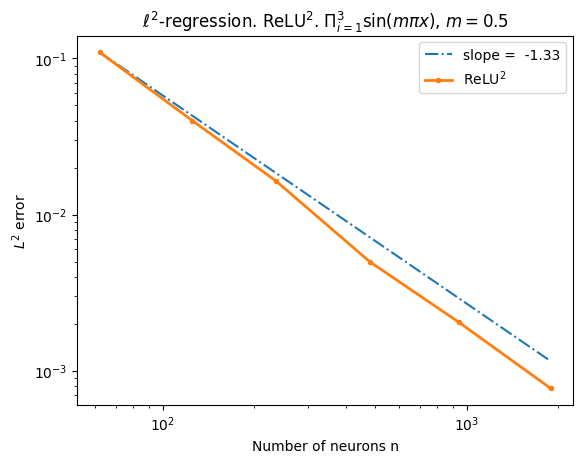

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
62.0 		 & 1.094e-01 &		 *  \\ \hline  

125.0 		 &  3.997e-02 &  		 1.44  \\ \hline  

235.0 		 &  1.647e-02 &  		 1.40  \\ \hline  

480.0 		 &  4.978e-03 &  		 1.68  \\ \hline  

939.0 		 &  2.051e-03 &  		 1.32  \\ \hline  

1887.0 		 &  7.706e-04 &  		 1.40  \\ \hline  



In [39]:
if relu_k == 1:
    title =f"$\ell^2$-regression. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m1}$"
else:
    title = f"$\ell^2$-regression. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m1}$"
# plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title)
# output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr)
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)


In [ ]:
## 4D

Number of neurons removed:  0
Number of neurons left:  64
Number of neurons removed:  1
Number of neurons left:  127
Number of neurons removed:  5
Number of neurons left:  251
Number of neurons removed:  4
Number of neurons left:  508
Number of neurons removed:  22
Number of neurons left:  1002
Number of neurons removed:  52
Number of neurons left:  1996


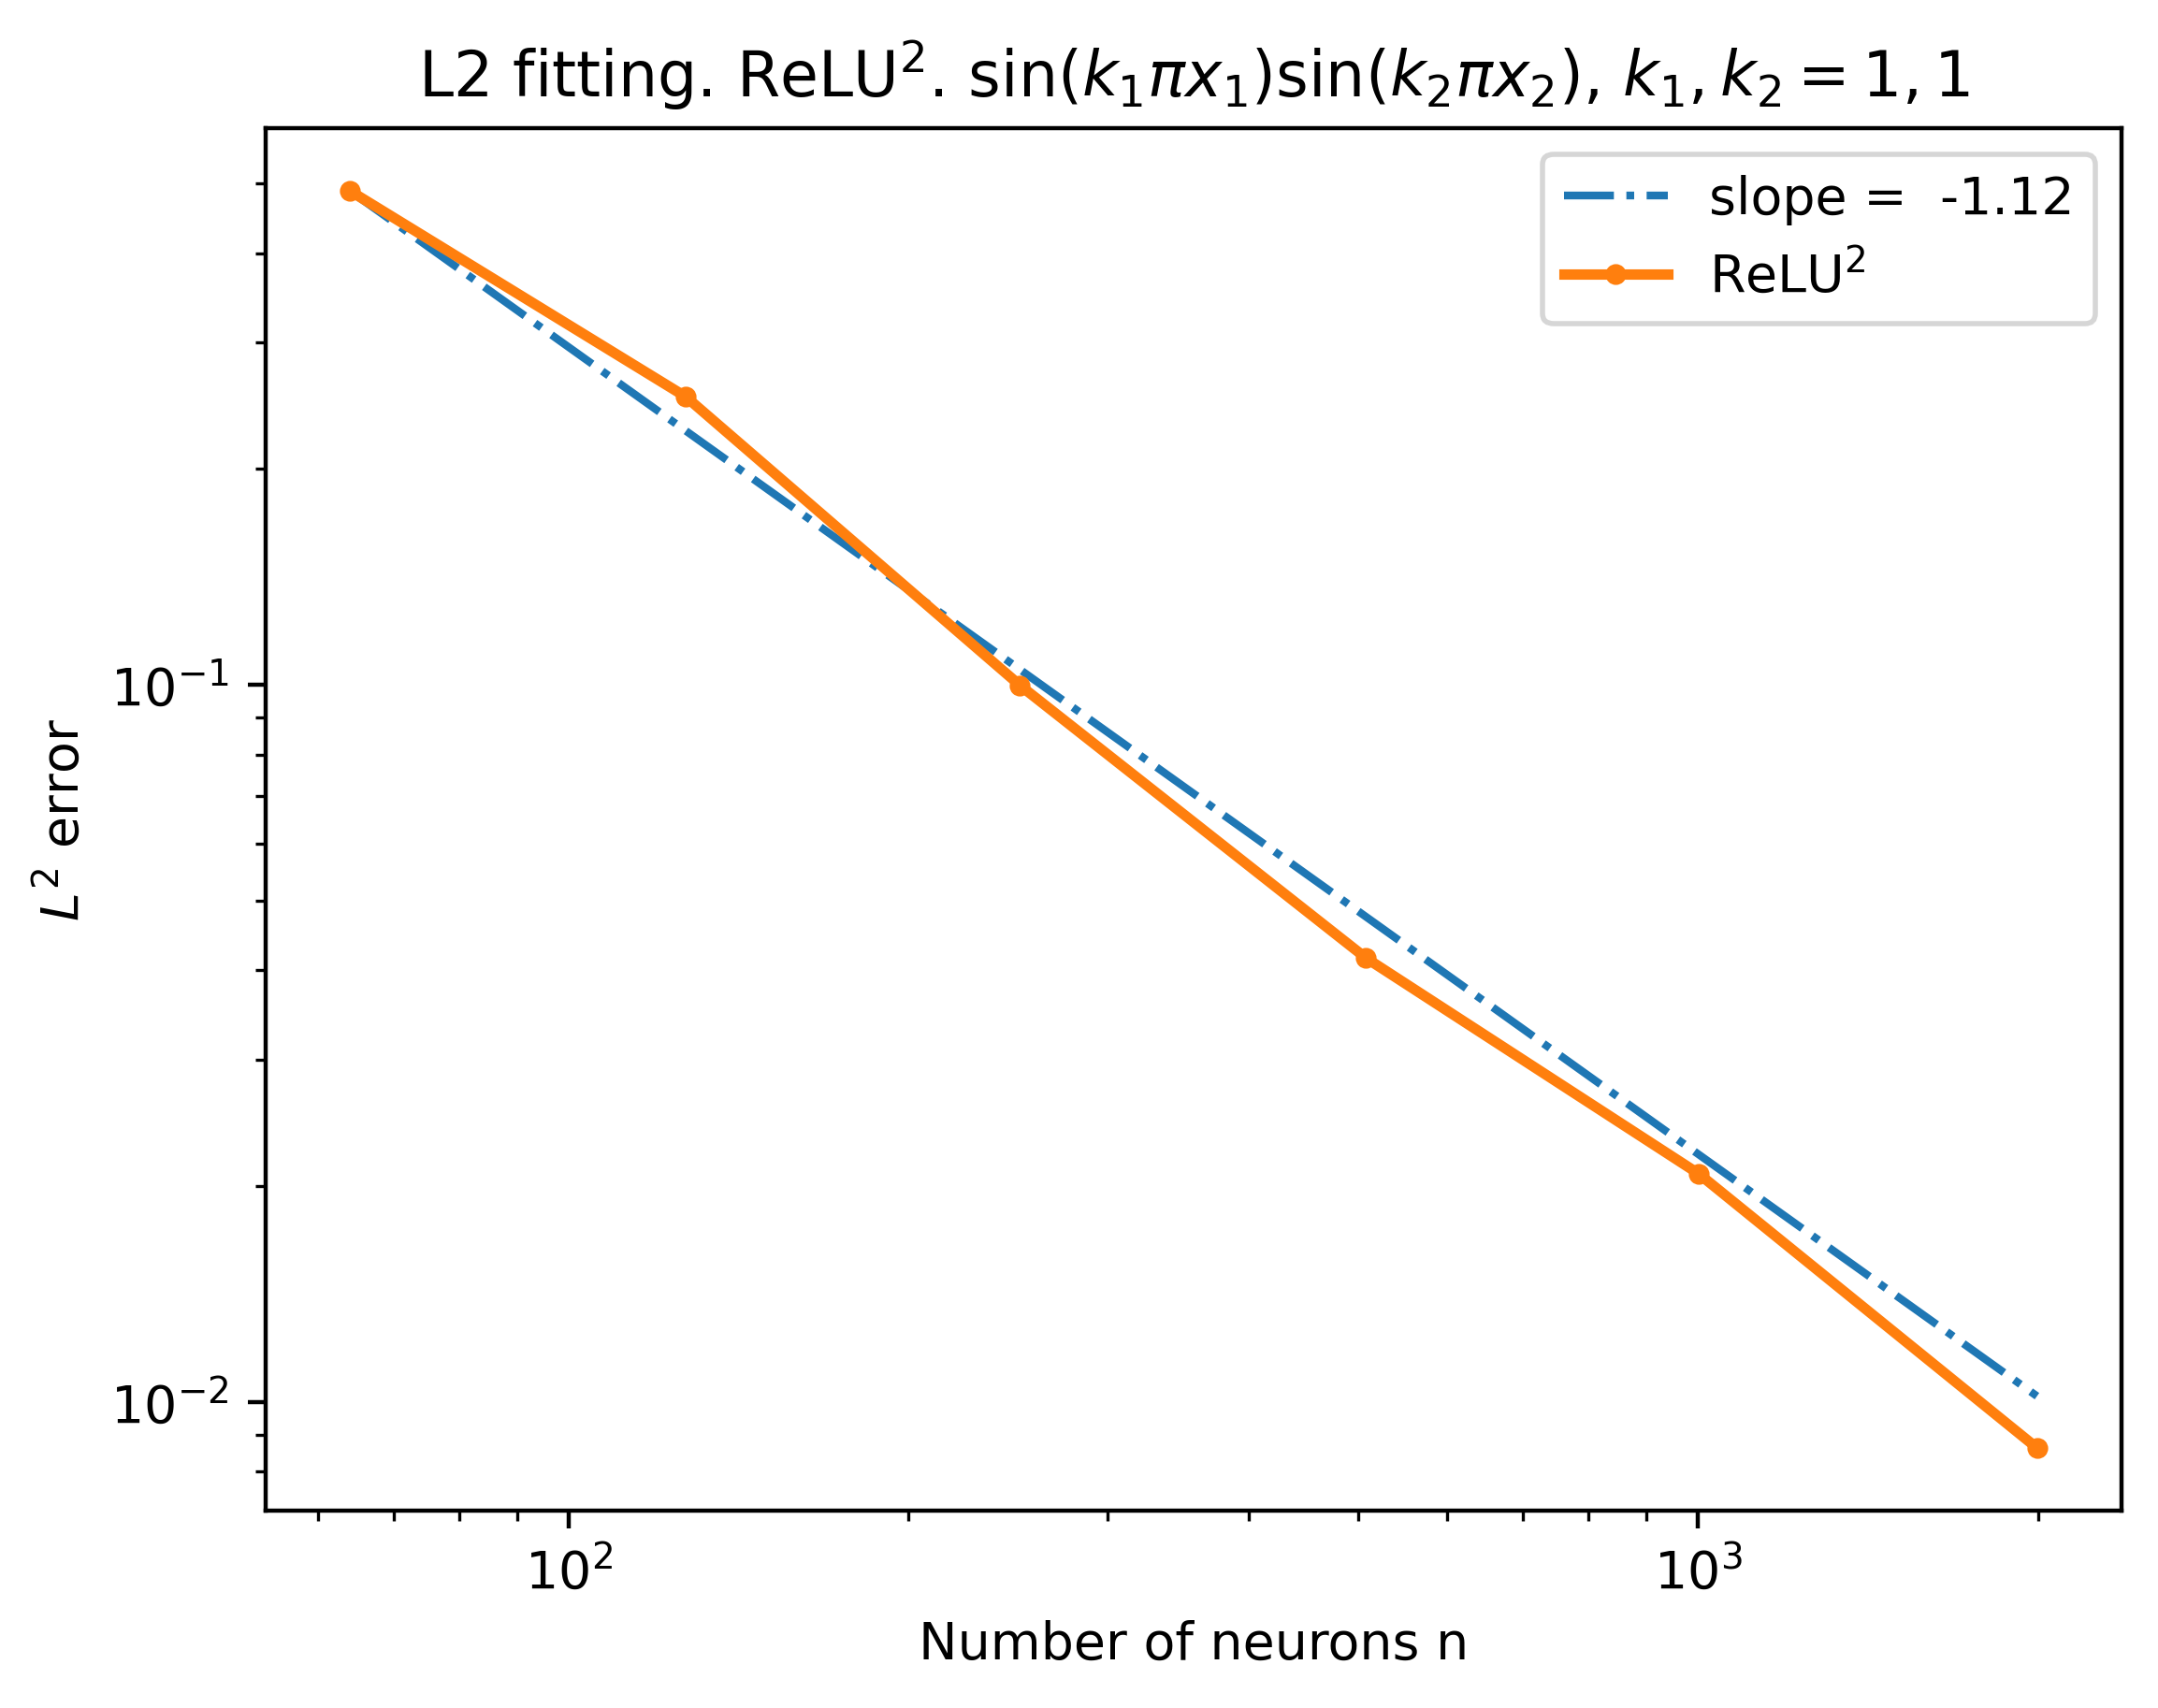

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
64.0 		 & 4.886e-01 &		 *  \\ \hline  

127.0 		 &  2.521e-01 &  		 0.97  \\ \hline  

251.0 		 &  9.983e-02 &  		 1.36  \\ \hline  

508.0 		 &  4.162e-02 &  		 1.24  \\ \hline  

1002.0 		 &  2.080e-02 &  		 1.02  \\ \hline  

1996.0 		 &  8.631e-03 &  		 1.28  \\ \hline  



In [43]:
m1 = 1/2 
m2 = 1/2  
m3 = 1/2 
m4 = 1/2 

def target(x): 
    z = torch.sin(m1 * pi *x[:,0:1])*torch.sin(m2 * pi *x[:,1:2] ) * torch.sin(m3 * pi *x[:,2:3]) * torch.sin(m4 * pi *x[:,3:4])  
    return z 
relu_k = 2  
d = 4 
# collocation points and weights 

integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(int(2e5), d, bl = -1, ur = 1)
integration_weights_test, integration_points_test = MonteCarlo_Sobol_dDim_weights_points(int(4e5), d, bl = -1, ur = 1)


mean_err_l2_list = [] # mean squared error 
mean_err_l2_list_2 = [] #exact L^2 error 
neuron_num_arr= np.array([2**i for i in range(6,12)]) 
actual_neuron_arr = np.zeros(len(neuron_num_arr)) 
for i,n in enumerate(neuron_num_arr): 
    trial_num = 1
    err_l2_trial = torch.zeros(trial_num) 
    err_l2_trial_2 = torch.zeros(trial_num)
    for trial in range(trial_num):
        #1. initialize model 
        my_model = model(d, n, 1, k=relu_k).to(device) 
        #2. remove redundant neurons
        my_model = initialize_model_2(my_model.cpu(), dim = d).to(device) 
        my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device)
        actual_neuron_arr[i] = my_model.fc1.bias.size(0) 
        D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
        D, b_rhs = rescale_mat_rhs(D,b_rhs)
        sol = scipy.linalg.lstsq(D.cpu().numpy(),b_rhs.cpu().numpy())[0]
        sol =torch.tensor(sol).to(device)
        my_model.fc2.weight.data[0,:] = sol.view(-1) 

        # with torch.no_grad(): 
        #     nn_func_values = my_model(x_test) 
        # target_values = target(x_test) 
        # target_norm = target_values.norm()
        # print(target_norm)
        # rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
        # err_l2_trial[trial] = rel_errl2 

        #evaluate error using exact Gauss quadrature rule
        with torch.no_grad():
            nn_func_values_2 = my_model(integration_points_test)
        target_values_2 = target(integration_points_test)
        # target_norm_2 = target_values_2.norm()
        rel_errl2_2 = integration_weights_test.t() @ (nn_func_values_2 - target_values_2)**2
        err_l2_trial_2[trial] = rel_errl2_2**0.5 

    mean_err_l2 = torch.mean(err_l2_trial) 
    mean_err_l2_list.append(mean_err_l2) 

    mean_err_l2_list_2.append(torch.mean(err_l2_trial_2))

mean_err_l2_arr = np.array(mean_err_l2_list) 
mean_err_l2_arr_2 = np.array(mean_err_l2_list_2) 

if relu_k == 1:
    title =f"$\ell^2$-regression. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m1}$"
else:
    title = f"$\ell^2$-regression. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m1}$"
# plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title)
# output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr)
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)



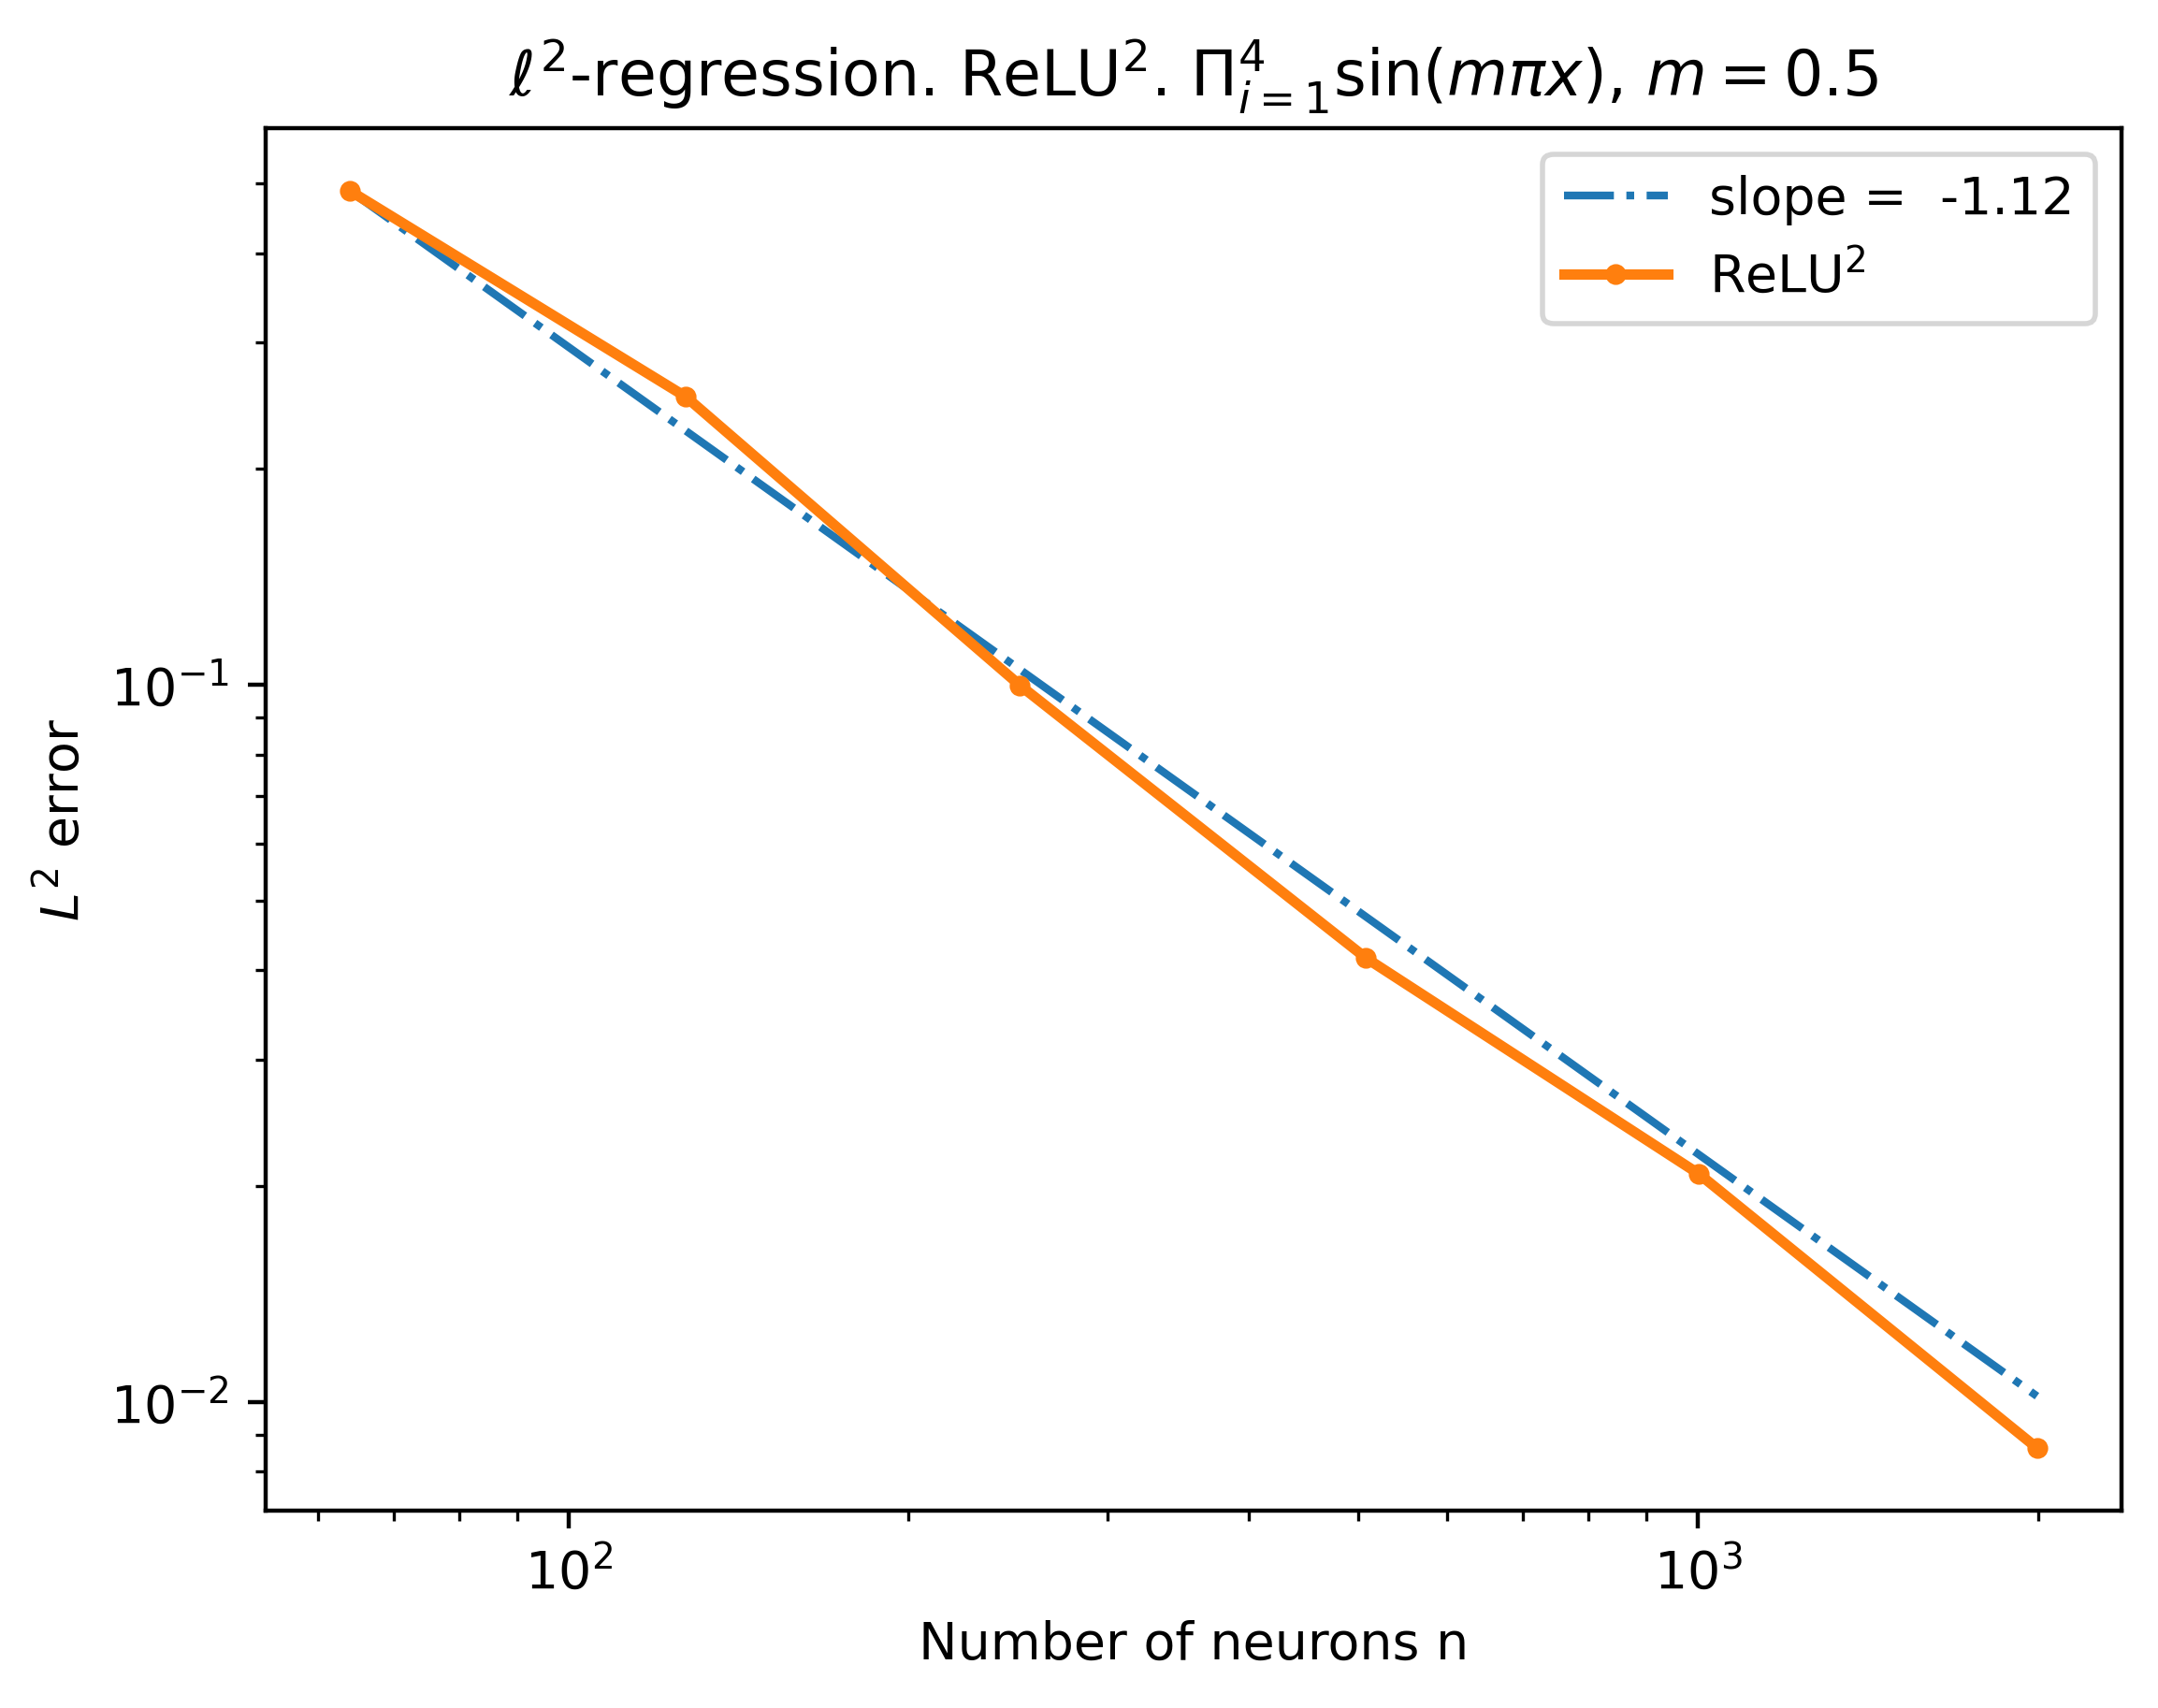

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
64.0 		 & 4.886e-01 &		 *  \\ \hline  

127.0 		 &  2.521e-01 &  		 0.97  \\ \hline  

251.0 		 &  9.983e-02 &  		 1.36  \\ \hline  

508.0 		 &  4.162e-02 &  		 1.24  \\ \hline  

1002.0 		 &  2.080e-02 &  		 1.02  \\ \hline  

1996.0 		 &  8.631e-03 &  		 1.28  \\ \hline  



In [44]:
if relu_k == 1:
    title =f"$\ell^2$-regression. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m1}$"
else:
    title = f"$\ell^2$-regression. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m1}$"
# plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title)
# output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr)
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)


Number of neurons removed:  1
Number of neurons left:  63
Number of neurons removed:  1
Number of neurons left:  127
Number of neurons removed:  1
Number of neurons left:  255
Number of neurons removed:  4
Number of neurons left:  508
Number of neurons removed:  1
Number of neurons left:  1023
Number of neurons removed:  9
Number of neurons left:  2039


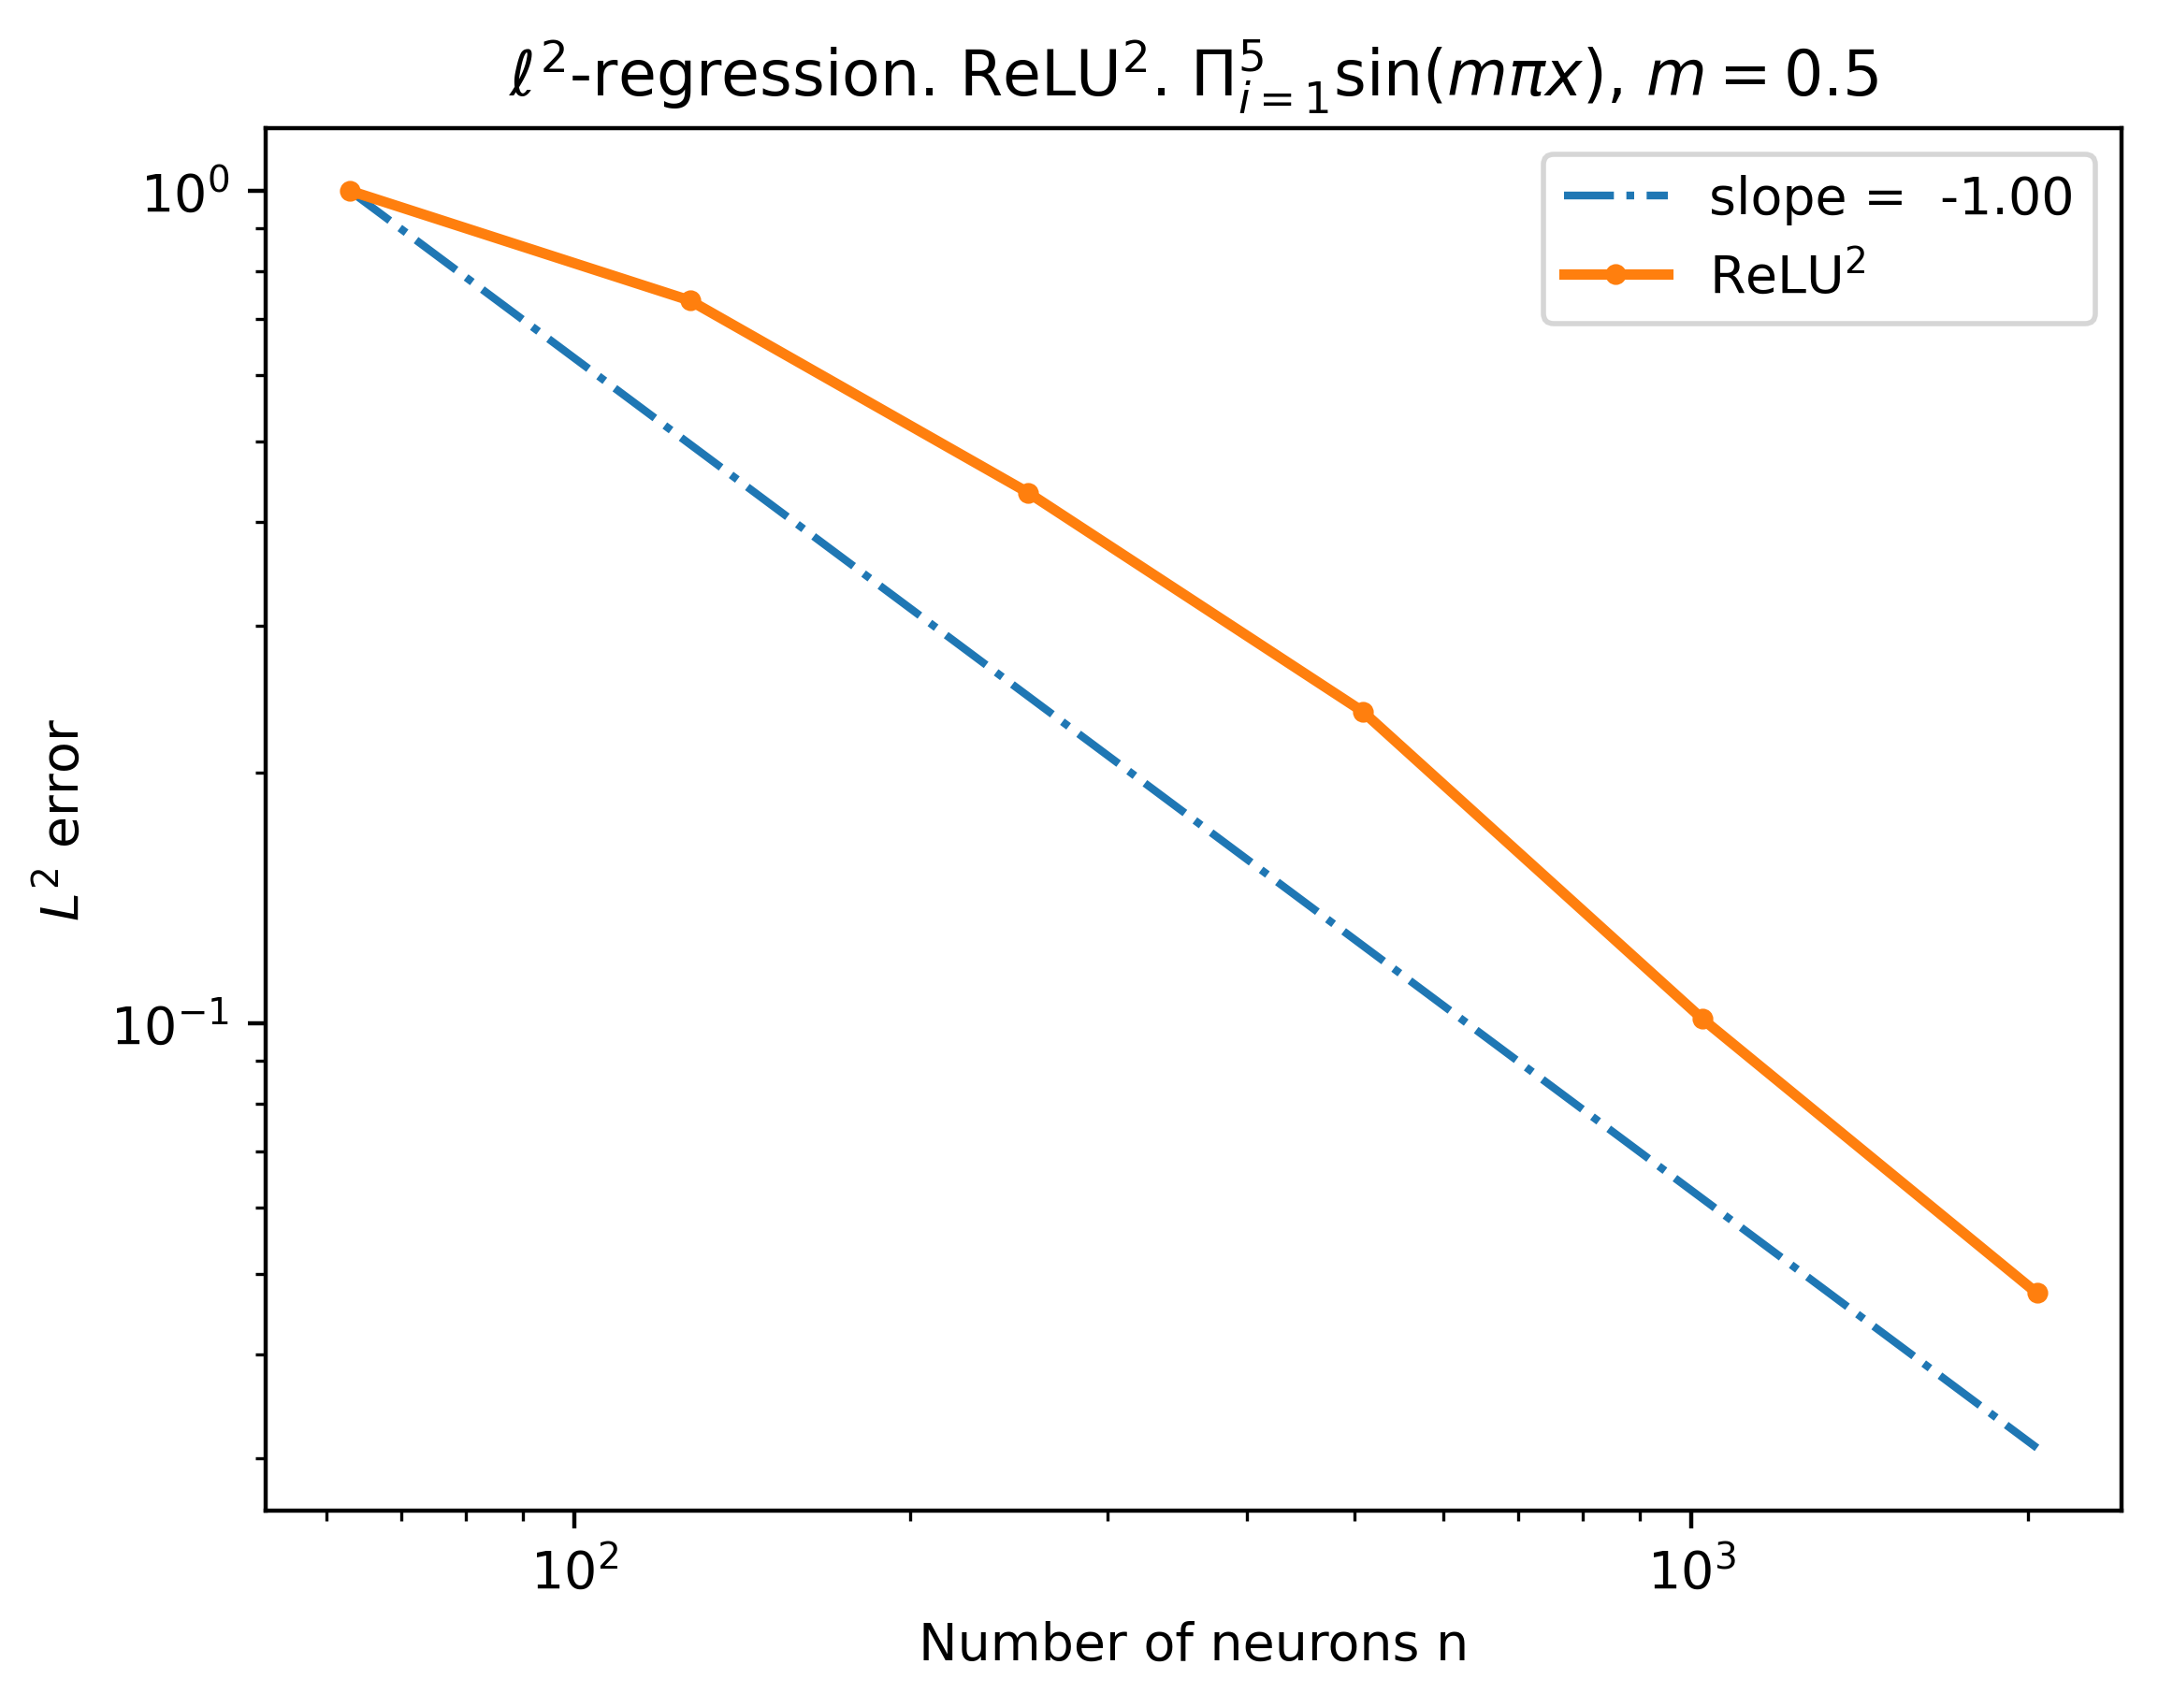

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
63.0 		 & 9.991e-01 &		 *  \\ \hline  

127.0 		 &  7.375e-01 &  		 0.43  \\ \hline  

255.0 		 &  4.335e-01 &  		 0.76  \\ \hline  

508.0 		 &  2.367e-01 &  		 0.88  \\ \hline  

1023.0 		 &  1.011e-01 &  		 1.21  \\ \hline  

2039.0 		 &  4.737e-02 &  		 1.10  \\ \hline  



In [47]:
## 5D 

m1 = 1/2 
m2 = 1/2  
m3 = 1/2 
m4 = 1/2 
m5 = 1/2 
def target(x): 
    z = torch.prod(torch.sin(m1 * pi * x),dim = 1,keepdim = True)
    return z  
relu_k = 2  
d = 5 
# collocation points and weights 

integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(int(4e5), d, bl = -1, ur = 1)
integration_weights_test, integration_points_test = MonteCarlo_Sobol_dDim_weights_points(int(8e5), d, bl = -1, ur = 1)


mean_err_l2_list = [] # mean squared error 
mean_err_l2_list_2 = [] #exact L^2 error 
neuron_num_arr= np.array([2**i for i in range(6,12)]) 
actual_neuron_arr = np.zeros(len(neuron_num_arr)) 
for i,n in enumerate(neuron_num_arr): 
    trial_num = 1
    err_l2_trial = torch.zeros(trial_num) 
    err_l2_trial_2 = torch.zeros(trial_num)
    for trial in range(trial_num):
        #1. initialize model 
        my_model = model(d, n, 1, k=relu_k).to(device) 
        #2. remove redundant neurons
        my_model = initialize_model_2(my_model.cpu(), dim = d).to(device) 
        my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device)
        actual_neuron_arr[i] = my_model.fc1.bias.size(0) 
        D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
        D, b_rhs = rescale_mat_rhs(D,b_rhs)
        sol = scipy.linalg.lstsq(D.cpu().numpy(),b_rhs.cpu().numpy())[0]
        sol =torch.tensor(sol).to(device)
        my_model.fc2.weight.data[0,:] = sol.view(-1) 

        # with torch.no_grad(): 
        #     nn_func_values = my_model(x_test) 
        # target_values = target(x_test) 
        # target_norm = target_values.norm()
        # print(target_norm)
        # rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
        # err_l2_trial[trial] = rel_errl2 

        #evaluate error using exact Gauss quadrature rule
        with torch.no_grad():
            nn_func_values_2 = my_model(integration_points_test)
        target_values_2 = target(integration_points_test)
        # target_norm_2 = target_values_2.norm()
        rel_errl2_2 = integration_weights_test.t() @ (nn_func_values_2 - target_values_2)**2
        err_l2_trial_2[trial] = rel_errl2_2**0.5 

    mean_err_l2 = torch.mean(err_l2_trial) 
    mean_err_l2_list.append(mean_err_l2) 

    mean_err_l2_list_2.append(torch.mean(err_l2_trial_2))

mean_err_l2_arr = np.array(mean_err_l2_list) 
mean_err_l2_arr_2 = np.array(mean_err_l2_list_2) 

if relu_k == 1:
    title =f"$\ell^2$-regression. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m1}$"
else:
    title = f"$\ell^2$-regression. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m1}$"
# plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title)
# output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr)
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)




Number of neurons removed:  0
Number of neurons left:  64
Number of neurons removed:  0
Number of neurons left:  128
Number of neurons removed:  0
Number of neurons left:  256
Number of neurons removed:  2
Number of neurons left:  510
Number of neurons removed:  2
Number of neurons left:  1022
Number of neurons removed:  4
Number of neurons left:  2044


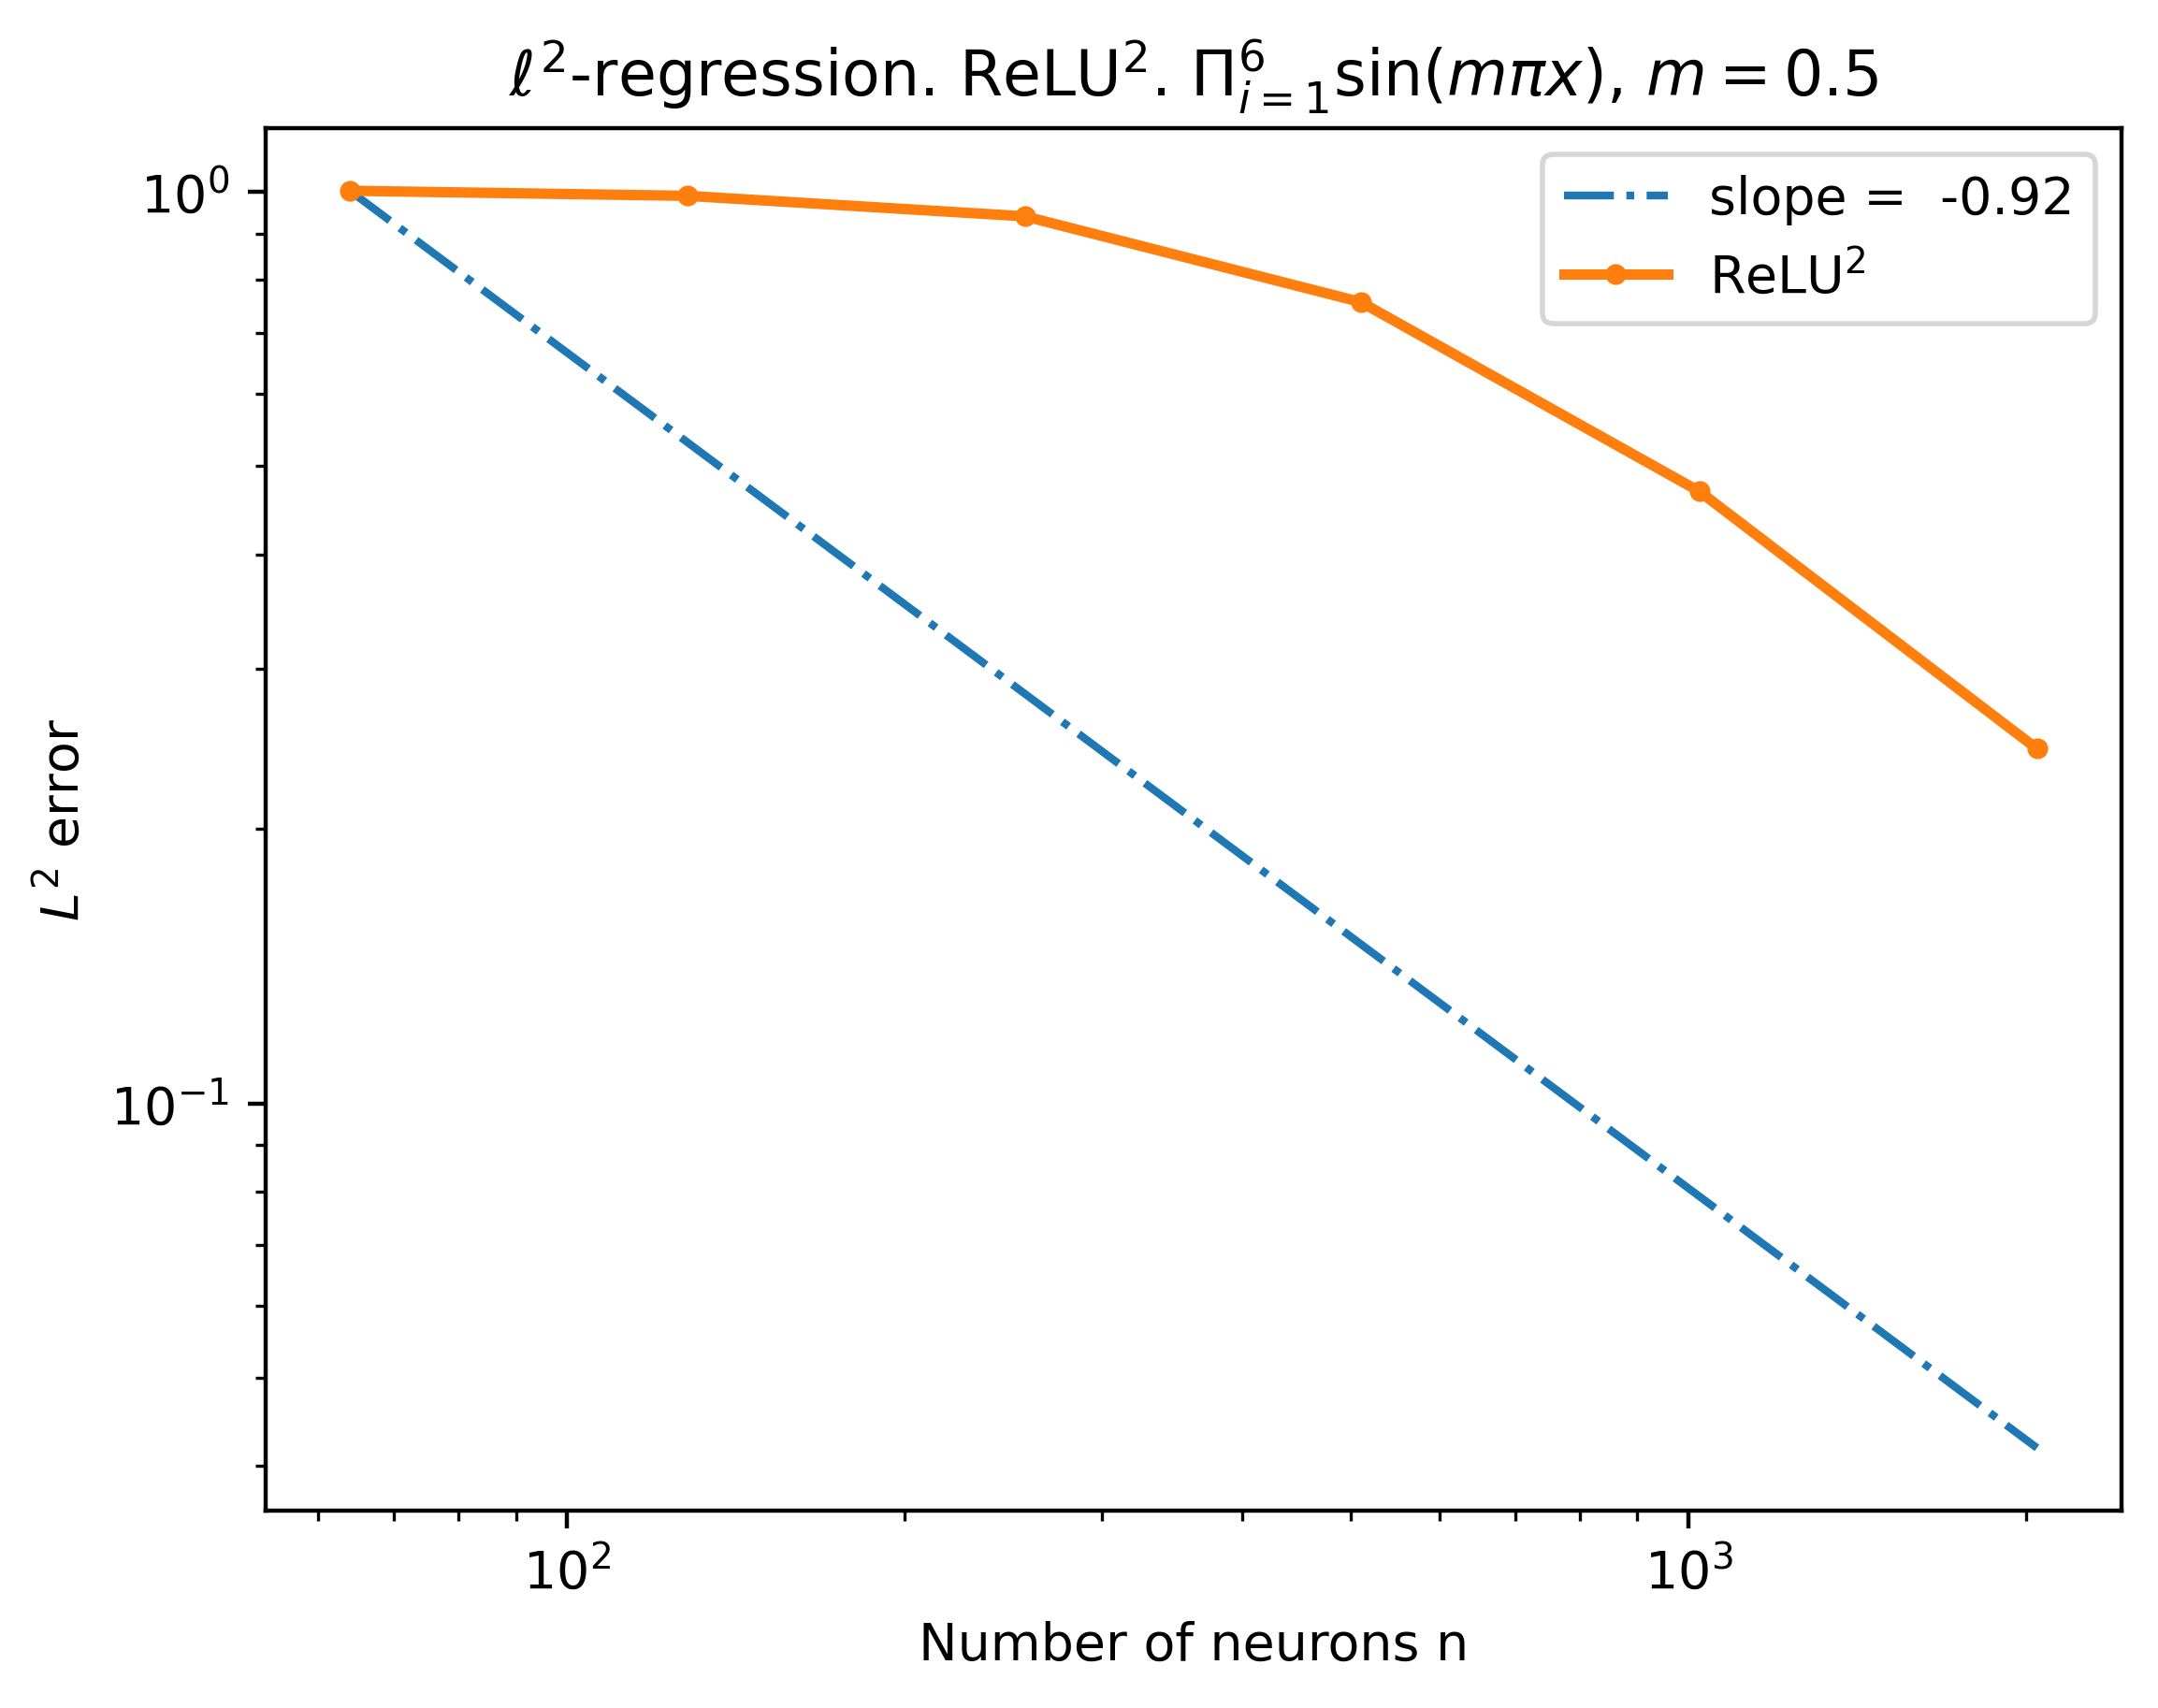

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
64.0 		 & 1.002e+00 &		 *  \\ \hline  

128.0 		 &  9.896e-01 &  		 0.02  \\ \hline  

256.0 		 &  9.396e-01 &  		 0.07  \\ \hline  

510.0 		 &  7.567e-01 &  		 0.31  \\ \hline  

1022.0 		 &  4.691e-01 &  		 0.69  \\ \hline  

2044.0 		 &  2.449e-01 &  		 0.94  \\ \hline  



In [48]:
## 6D

m1 = 1/2 
m2 = 1/2  
m3 = 1/2 
m4 = 1/2 
m5 = 1/2 
m6 = 1/2 
def target(x): 
    z = torch.prod(torch.sin(m1 * pi * x),dim = 1,keepdim = True)
    return z  
relu_k = 2  
d = 6  
# collocation points and weights 

integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(int(4e5), d, bl = -1, ur = 1)
integration_weights_test, integration_points_test = MonteCarlo_Sobol_dDim_weights_points(int(8e5), d, bl = -1, ur = 1)


mean_err_l2_list = [] # mean squared error 
mean_err_l2_list_2 = [] #exact L^2 error 
neuron_num_arr= np.array([2**i for i in range(6,12)]) 
actual_neuron_arr = np.zeros(len(neuron_num_arr)) 
for i,n in enumerate(neuron_num_arr): 
    trial_num = 1
    err_l2_trial = torch.zeros(trial_num) 
    err_l2_trial_2 = torch.zeros(trial_num)
    for trial in range(trial_num):
        #1. initialize model 
        my_model = model(d, n, 1, k=relu_k).to(device) 
        #2. remove redundant neurons
        my_model = initialize_model_2(my_model.cpu(), dim = d).to(device) 
        my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device)
        actual_neuron_arr[i] = my_model.fc1.bias.size(0) 
        D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
        D, b_rhs = rescale_mat_rhs(D,b_rhs)
        sol = scipy.linalg.lstsq(D.cpu().numpy(),b_rhs.cpu().numpy())[0]
        sol =torch.tensor(sol).to(device)
        my_model.fc2.weight.data[0,:] = sol.view(-1) 

        # with torch.no_grad(): 
        #     nn_func_values = my_model(x_test) 
        # target_values = target(x_test) 
        # target_norm = target_values.norm()
        # print(target_norm)
        # rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
        # err_l2_trial[trial] = rel_errl2 

        #evaluate error using exact Gauss quadrature rule
        with torch.no_grad():
            nn_func_values_2 = my_model(integration_points_test)
        target_values_2 = target(integration_points_test)
        # target_norm_2 = target_values_2.norm()
        rel_errl2_2 = integration_weights_test.t() @ (nn_func_values_2 - target_values_2)**2
        err_l2_trial_2[trial] = rel_errl2_2**0.5 

    mean_err_l2 = torch.mean(err_l2_trial) 
    mean_err_l2_list.append(mean_err_l2) 

    mean_err_l2_list_2.append(torch.mean(err_l2_trial_2))

mean_err_l2_arr = np.array(mean_err_l2_list) 
mean_err_l2_arr_2 = np.array(mean_err_l2_list_2) 

if relu_k == 1:
    title =f"$\ell^2$-regression. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m1}$"
else:
    title = f"$\ell^2$-regression. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m1}$"
# plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title)
# output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr)
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)




Number of neurons removed:  0
Number of neurons left:  64
Number of neurons removed:  0
Number of neurons left:  128
Number of neurons removed:  0
Number of neurons left:  256
Number of neurons removed:  0
Number of neurons left:  512
Number of neurons removed:  1
Number of neurons left:  1023
Number of neurons removed:  2
Number of neurons left:  2046
Number of neurons removed:  8
Number of neurons left:  4088


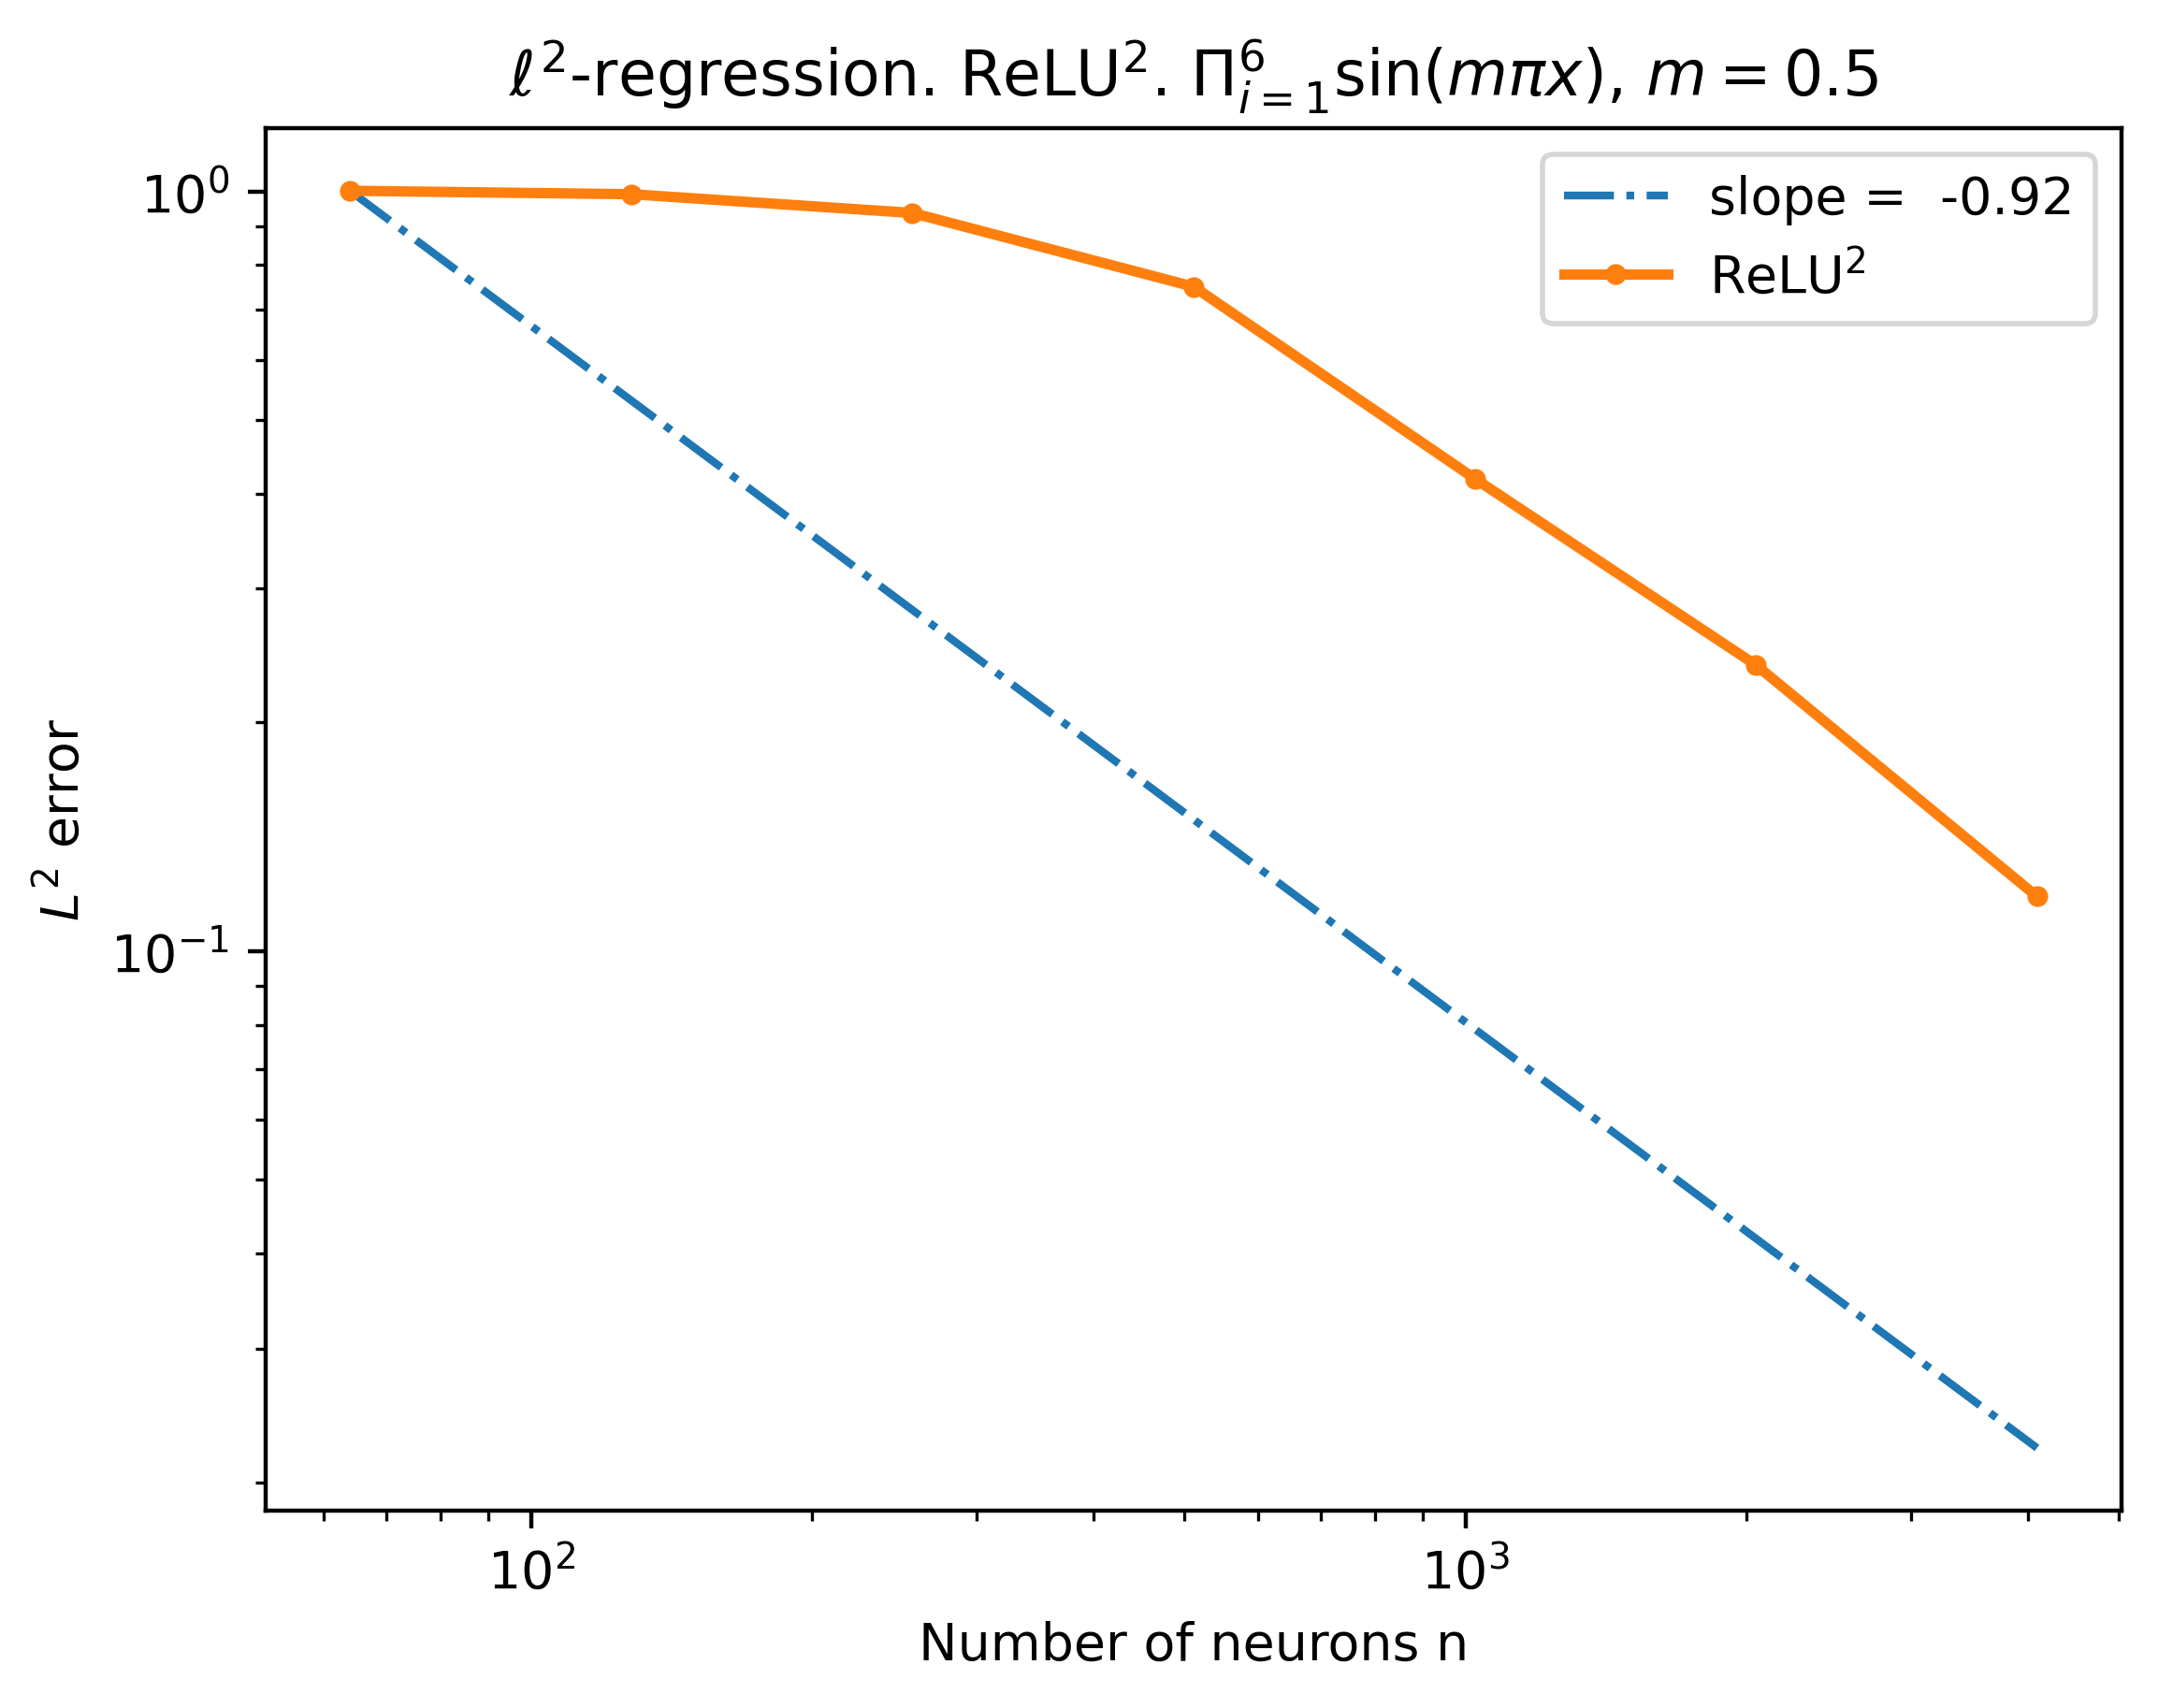

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
64.0 		 & 1.002e+00 &		 *  \\ \hline  

128.0 		 &  9.919e-01 &  		 0.01  \\ \hline  

256.0 		 &  9.369e-01 &  		 0.08  \\ \hline  

512.0 		 &  7.492e-01 &  		 0.32  \\ \hline  

1023.0 		 &  4.189e-01 &  		 0.84  \\ \hline  

2046.0 		 &  2.380e-01 &  		 0.82  \\ \hline  

4088.0 		 &  1.180e-01 &  		 1.01  \\ \hline  



In [49]:
## 6D

m1 = 1/2 
m2 = 1/2  
m3 = 1/2 
m4 = 1/2 
m5 = 1/2 
m6 = 1/2 
def target(x): 
    z = torch.prod(torch.sin(m1 * pi * x),dim = 1,keepdim = True)
    return z  
relu_k = 2  
d = 6  
# collocation points and weights 

integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(int(4e5), d, bl = -1, ur = 1)
integration_weights_test, integration_points_test = MonteCarlo_Sobol_dDim_weights_points(int(8e5), d, bl = -1, ur = 1)


mean_err_l2_list = [] # mean squared error 
mean_err_l2_list_2 = [] #exact L^2 error 
neuron_num_arr= np.array([2**i for i in range(6,13)]) 
actual_neuron_arr = np.zeros(len(neuron_num_arr)) 
for i,n in enumerate(neuron_num_arr): 
    trial_num = 1
    err_l2_trial = torch.zeros(trial_num) 
    err_l2_trial_2 = torch.zeros(trial_num)
    for trial in range(trial_num):
        #1. initialize model 
        my_model = model(d, n, 1, k=relu_k).to(device) 
        #2. remove redundant neurons
        my_model = initialize_model_2(my_model.cpu(), dim = d).to(device) 
        my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device)
        actual_neuron_arr[i] = my_model.fc1.bias.size(0) 
        D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
        D, b_rhs = rescale_mat_rhs(D,b_rhs)
        sol = scipy.linalg.lstsq(D.cpu().numpy(),b_rhs.cpu().numpy())[0]
        sol =torch.tensor(sol).to(device)
        my_model.fc2.weight.data[0,:] = sol.view(-1) 

        # with torch.no_grad(): 
        #     nn_func_values = my_model(x_test) 
        # target_values = target(x_test) 
        # target_norm = target_values.norm()
        # print(target_norm)
        # rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
        # err_l2_trial[trial] = rel_errl2 

        #evaluate error using exact Gauss quadrature rule
        with torch.no_grad():
            nn_func_values_2 = my_model(integration_points_test)
        target_values_2 = target(integration_points_test)
        # target_norm_2 = target_values_2.norm()
        rel_errl2_2 = integration_weights_test.t() @ (nn_func_values_2 - target_values_2)**2
        err_l2_trial_2[trial] = rel_errl2_2**0.5 

    mean_err_l2 = torch.mean(err_l2_trial) 
    mean_err_l2_list.append(mean_err_l2) 

    mean_err_l2_list_2.append(torch.mean(err_l2_trial_2))

mean_err_l2_arr = np.array(mean_err_l2_list) 
mean_err_l2_arr_2 = np.array(mean_err_l2_list_2) 

if relu_k == 1:
    title =f"$\ell^2$-regression. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m1}$"
else:
    title = f"$\ell^2$-regression. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m1}$"
# plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title)
# output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr)
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)


